# Load groundwork 

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as colors

import scanpy as sc

import os

import scvi

import seaborn as sns

%matplotlib inline

def order_m(m):
    n = min(*m.shape)
    
    ordered_cols = []
    remain_cols = list(range(m.shape[1]))
    
    for i in range(n):
        ic = m[i, remain_cols].argmax()
        c = remain_cols[ic]
        ordered_cols.append(c)
        remain_cols.remove(c)
    
    return ordered_cols, remain_cols




canonical_markers = ["IL32", "LTB", "CD3D",
    "IL7R", "LDHB", "FCGR3A", 
    "CD68", "MS4A1", "GNLY", 
    "CD3E", "CD14", "CD14", 
    "FCGR3A", "LYZ", "PPBP", 
    "CD8A", "PPBP", "CST3", 
    "NKG7", "MS4A7", "MS4A1", 
    "CD8A", "CD4", "NCAM1"]

    

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndat

In [2]:
## Downloaded CR-arc count matrix results
data_dir = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/downloaded_counts/VIB_10xmultiome_2'

h5_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2-outs-raw_feature_bc_matrix-matrix.h5ad')

barcodes_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2.barcodes.tsv')

features_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2.features.tsv')

h5 = sc.read_h5ad(h5_file)

features_pd = pd.read_csv(features_file, header=None, sep='\t')

barcodes_pd = pd.read_csv(barcodes_file, header=None, sep='\t')

## It's feature -by- barcode matrix, need to transpose
h5.var = barcodes_pd
h5.obs = features_pd 
h5.obs.columns = ['feature_id', 'name', 'feature_type', 'chrom', 'start', 'end']
h5.var.columns = ['barcodes']


## Entropy filtered atac
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000_test_norm'
entropy_downstream_dir = os.path.join(entropy_dir, 'DownstreamReanalysis')
entropy_peak_file = os.path.join(entropy_downstream_dir, 'entropy_peakvi.h5ad')
peak_file = os.path.join(entropy_downstream_dir, 'standard_peakvi.h5ad')

entropy_peak = sc.read_h5ad(entropy_peak_file)
peak = sc.read_h5ad(peak_file)

# Rename peakvi clustering columns
entropy_peak.obs['clusters_peakvi_entropy'] = entropy_peak.obs['clusters_peakvi']
peak.obs['clusters_peakvi_standard'] = peak.obs['clusters_peakvi']

# Load entropy score and add to entropy_peak obs
entropy_score_file = os.path.join(entropy_dir, 'entropy_filtered_bc_df.tsv')
entropy_score_pd = pd.read_csv(entropy_score_file, sep=',', index_col=0)
entropy_peak.obs = entropy_peak.obs.merge(entropy_score_pd[['Entropy', 'Entropy_open_region']], left_on='barcodes', right_index=True, how='left')

# atac clsutering at higher resolutions (than previously used)
atac_resolution = 0.5
sc.tl.leiden(entropy_peak, key_added='clusters_peakvi_highres_entropy', resolution=atac_resolution)
sc.tl.leiden(peak, key_added='clusters_peakvi_highres_standard', resolution=atac_resolution)


# atac-rna-barcode map 
bc_map_file = '/home/syyang/adipose_ln/multiom/atac_rna_barcodes_map.tsv'
bc_map_pd = pd.read_csv(bc_map_file, sep='\t')




## load peakvi models for DARS analysis 
standard_peak_model_dir = os.path.join(entropy_downstream_dir, 'standard_peak_peakvi_model')
entropy_peak_model_dir =os.path.join(entropy_downstream_dir, 'entropy_peak_peakvi_model')
standard_peak_model =scvi.model.PEAKVI.load(standard_peak_model_dir, adata=peak)
entropy_peak_model =scvi.model.PEAKVI.load(entropy_peak_model_dir, adata=entropy_peak)


# Summary statistics about Fraction of Reads in Peaks (FRIP)
standard_peak_frip_file = os.path.join(entropy_dir, 'fragments_overlap_peaks', 'summary_statistics_frag_overlap_peaks.csv')
entropy_peak_frip_file = os.path.join(entropy_dir, 'fragments_overlap_peaks', 'summary_statistics_frag_overlap_entropypeaks.csv')


standard_peak_frip = pd.read_csv(standard_peak_frip_file, index_col=None, sep='\t')
entropy_peak_frip = pd.read_csv(entropy_peak_frip_file, index_col=None, sep='\t')
standard_peak_frip.rename(columns={'1': 'barcode'}, inplace=True)
entropy_peak_frip.rename(columns={'1': 'barcode'}, inplace=True)
entropy_peak_frip['atac_bc'] = entropy_peak_frip['barcode'].str.split('-1').str[0]
standard_peak_frip['atac_bc'] = standard_peak_frip['barcode'].str.split('-1').str[0]
standard_peak_frip.set_index('atac_bc', inplace=True)
entropy_peak_frip.set_index('atac_bc', inplace=True)

/tmp/ipykernel_618038/2704537721.py:43: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(entropy_peak, key_added='clusters_peakvi_highres_entropy', resolution=atac_resolution)


INFO     File                                                                                                      
         /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000_test_norm/DownstreamReanalysis/standard_peak_pe
         akvi_model/model.pt already downloaded                                                                    
INFO     File                                                                                                      
         /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000_test_norm/DownstreamReanalysis/entropy_peak_pea
         kvi_model/model.pt already downloaded                                                                     


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_

In [3]:
entropy_peak, peak, h5, features_pd.shape, barcodes_pd.shape, bc_map_pd.shape

(AnnData object with n_obs × n_vars = 2126 × 36730
     obs: 'barcodes', '_scvi_batch', '_scvi_labels', 'clusters_peakvi', 'clusters_peakvi_entropy', 'Entropy', 'Entropy_open_region', 'clusters_peakvi_highres_entropy'
     var: 'peak'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'clusters_peakvi', 'neighbors', 'umap', 'clusters_peakvi_highres_entropy'
     obsm: 'X_peakvi', 'X_umap'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 2126 × 31116
     obs: 'barcodes', '_scvi_batch', '_scvi_labels', 'clusters_peakvi', 'clusters_peakvi_standard', 'clusters_peakvi_highres_standard'
     var: 'peak'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'clusters_peakvi', 'neighbors', 'umap', 'clusters_peakvi_highres_standard'
     obsm: 'X_peakvi', 'X_umap'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 104068 × 687495
     obs: 'feature_id', 'name', 'feature_type', 'chrom', 'start', 'end'
     var: 'barcodes',
 (104068, 6),
 (687495, 1

# Matching atac bc with RNA bc

In [4]:
bc_map = bc_map_pd.set_index('atac_barcodes')

entropy_peak.obs['atac_bc'] =  entropy_peak.obs['barcodes'].map(lambda x: x.split('-1')[0])
entropy_peak.obs.set_index('atac_bc', inplace=True)
if 'rna_barcodes' not in entropy_peak.obs.columns:
    entropy_peak.obs = entropy_peak.obs.join(bc_map, how='inner')


peak.obs['atac_bc'] =  peak.obs['barcodes'].map(lambda x: x.split('-1')[0])
peak.obs.set_index('atac_bc', inplace=True)
if 'rna_barcodes' not in peak.obs.columns:
    peak.obs = peak.obs.join(bc_map, how='inner')


bc_passed_entropy_df = entropy_peak.obs[['rna_barcodes']]

# RNA clustering

## VIS

In [5]:
# prepare for rna-bc correspondence to atac entropy filtered barcodes
entropy_passed_bc_map=bc_passed_entropy_df.reset_index(inplace=False)
entropy_passed_bc_map.set_index('rna_barcodes', inplace=True)
entropy_passed_bc_map.columns = ['atac_bc']


h5_rna_ = h5.transpose()
h5_rna_.obs['rna_barcodes'] = h5_rna_.obs['barcodes'].map(lambda x: x.split('-1')[0])
h5_rna_.obs.set_index('rna_barcodes', inplace=True)


# select gene expression only, and only the barcodes that passed entropy filtering
h5_rna_ = h5_rna_[:, h5_rna_.var['feature_type'] == 'Gene Expression']
h5_rna_ = h5_rna_[h5_rna_.obs.index.isin(entropy_passed_bc_map.index), :]
h5_rna_.obs = h5_rna_.obs.join(entropy_passed_bc_map, how='inner')

# calculate total RNA QC metrics
h5_rna_.obs['total_RNA_UMI'] = h5_rna_.X.sum(axis=1)
h5_rna_.obs['total_RNA_UMI_log'] = np.log1p(h5_rna_.obs['total_RNA_UMI'])
h5_rna_.obs['n_genes_by_RNA_counts'] = (h5_rna_.X > 0).sum(axis=1)
h5_rna_.obs['N_MT_counts'] = h5_rna_.X[:, h5_rna_.var.name.apply(lambda x: x.startswith('MT-'))].sum(axis=1)
h5_rna_.obs['MT%'] = h5_rna_.obs['N_MT_counts'] / h5_rna_.obs['total_RNA_UMI'] * 100

X_10k = sc.pp.normalize_total(h5_rna_, target_sum=1e4, inplace=False)['X']
h5_rna_.layers['log1p_counts'] = np.log1p(X_10k.copy())

h5_rna = h5_rna_[:, ~h5_rna_.var.name.apply(lambda x: x.startswith('MT-'))].copy() # Remove MT genes

# Add gene_name column 
h5_rna.var['gene_name'] = h5_rna.var['name'].astype(str)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


In [6]:
h5_rna, h5_rna_.shape

(AnnData object with n_obs × n_vars = 2126 × 36588
     obs: 'barcodes', 'atac_bc', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%'
     var: 'feature_id', 'name', 'feature_type', 'chrom', 'start', 'end', 'gene_name'
     layers: 'log1p_counts',
 (2126, 36601))

In [7]:
sc.pp.filter_genes(h5_rna, min_counts=3)
h5_rna.raw = h5_rna # keep full dimension safe
h5_rna.layers['counts'] = h5_rna.X
sc.pp.highly_variable_genes(
h5_rna,
flavor="seurat_v3",
n_top_genes=4000,
layer="counts",
subset=False)

In [8]:
scvi.settings.seed = 0
scvi.model.SCVI.setup_anndata(h5_rna, layer="counts")
vae = scvi.model.SCVI(h5_rna, n_layers=3, n_latent=30, gene_likelihood="nb")
vae.train()
h5_rna.obsm["RNA_scVI"] = vae.get_latent_representation()

sc.pp.neighbors(h5_rna, use_rep='RNA_scVI')
sc.tl.umap(h5_rna, min_dist=0.3)

print("Save integrated samples into .h5ad file and trained SCVI model into subfolder\n") 
vae_model_folder=os.path.join(entropy_dir, "_RNA_scvi_model")
vae.save(vae_model_folder, overwrite=True)
# vae_model_folder=os.path.join(entropy_dir, "_RNA_scvi_model")
# vae =scvi.model.SCVI.load(vae_model_folder, adata=h5_rna)
# h5_rna.obsm["RNA_scVI"] = vae.get_latent_representation()
# sc.pp.neighbors(h5_rna, use_rep='RNA_scVI')
# sc.tl.umap(h5_rna, min_dist=0.3)


Seed set to 0
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/_scvi.py:168: UserWarning: This dataset has some empty cells, this might fail inference.Data should be filtered with `scanpy.pp.filter_cells()`
  library_log_means, library_log_vars = _init_library_size(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/gener

Epoch 400/400: 100%|██████████| 400/400 [01:35<00:00,  4.49it/s, v_num=1, train_loss_step=5.14e+3, train_loss_epoch=5.21e+3]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [01:35<00:00,  4.19it/s, v_num=1, train_loss_step=5.14e+3, train_loss_epoch=5.21e+3]
Save integrated samples into .h5ad file and trained SCVI model into subfolder



In [9]:
# clustering using scVI latent representation via Leiden
sc.tl.leiden(h5_rna, key_added="leiden_RNA_scVI", resolution=atac_resolution + 0.1)

In [10]:
# See concordance between two clustering results between Standard peak clustering and Entropy filtered peak clustering
entropy_peak_df = entropy_peak.obs.copy()
entropy_peak_df.set_index('barcodes', inplace=True)

peak_df = peak.obs.copy()
peak_df.set_index('barcodes', inplace=True)

In [11]:
if 'Entropy' in h5_rna.obs.columns:
    h5_rna.obs.drop(columns=['Entropy'], inplace=True)  
if 'Entropy_open_region' in h5_rna.obs.columns:
    h5_rna.obs.drop(columns=['Entropy_open_region'], inplace=True)
    
h5_rna.obs = h5_rna.obs.merge(entropy_peak.obs[['Entropy', 'Entropy_open_region']], left_on='atac_bc', right_index=True, how='left')
h5_rna.obs['Entropy_log'] = np.log10(h5_rna.obs['Entropy'])


if 'total_atac_fragments' in h5_rna.obs.columns:
    h5_rna.obs.drop(columns=['total_atac_fragments'], inplace=True)
h5_rna.obs = h5_rna.obs.merge(entropy_peak_frip[['total_fragments']].rename(columns={'total_fragments': 'total_atac_fragments'}), \
    left_on='atac_bc', right_index=True, how='left')

h5_rna.obs['total_atac_fragments_log1p'] = np.log1p(h5_rna.obs['total_atac_fragments'])

## Provide cluster to cell-type map

In [ ]:
# Juliana's cell type annotation
RNAcluster_celltype_map = {
'0': 'CD14+ Mo',
'1': 'CD4+CD8+ naive T cells',
'2': 'Tregs',
'3': 'B cells',
'4': 'ILC/NK cells',
'5': 'MAIT/NK T cells',
'6': 'gammaSignma T cells',
'7': 'Unknown',
'8': 'CD16+Mo',
'9': 'pDCs',
'10': 'Plasma cells (noisy)'
}

h5_rna.obs['celltype'] = h5_rna.obs['leiden_RNA_scVI'].map(RNAcluster_celltype_map)

## do NOT !!! delete 
## do NOT !!! delete 
## do NOT !!! delete 


# # ## Save each cell-type's barcode 
# rna_cell_type_subdir = os.path.join(entropy_dir,  '_rna_cell_types')
# os.makedirs(rna_cell_type_subdir, exist_ok=True)

# #
# for cluster in h5_rna.obs['leiden_RNA_scVI'].unique():
#     write_file = 'RNAcluster_' + str(cluster) + '_df.csv' 
#     write_file_path = os.path.join(rna_cell_type_subdir, write_file)
#     h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == cluster, :].to_csv(write_file_path, index=False)
    
# # write cell-type mapping file
# celltype_map_file = os.path.join(rna_cell_type_subdir, 'RNAcluster_celltype_map.tsv')
# with open(celltype_map_file, 'w') as f:
#     for k, v in RNAcluster_celltype_map.items():
#         f.write(f"{k}\t{v}\n")

### plot to see cell-type fraction of reads in peaks (FRIP) for standard peak set and entropy peak set

In [13]:
if 'standard_peak_FRIP' in h5_rna.obs.columns:
    h5_rna.obs.drop(columns=['standard_peak_FRIP'], inplace=True)
if 'entropy_peak_FRIP' in h5_rna.obs.columns:
    h5_rna.obs.drop(columns=['entropy_peak_FRIP'], inplace=True)
    
h5_rna.obs = h5_rna.obs.merge(standard_peak_frip[['frag_overlap_peaks%']].rename(columns={'frag_overlap_peaks%': 'standard_peak_FRIP'}),\
    left_on='atac_bc', right_index=True, how='left')

h5_rna.obs = h5_rna.obs.merge(entropy_peak_frip[['frag_overlap_entropy_peaks%']].rename(columns={'frag_overlap_entropy_peaks%': 'entropy_peak_FRIP'}),\
    left_on='atac_bc', right_index=True, how='left')


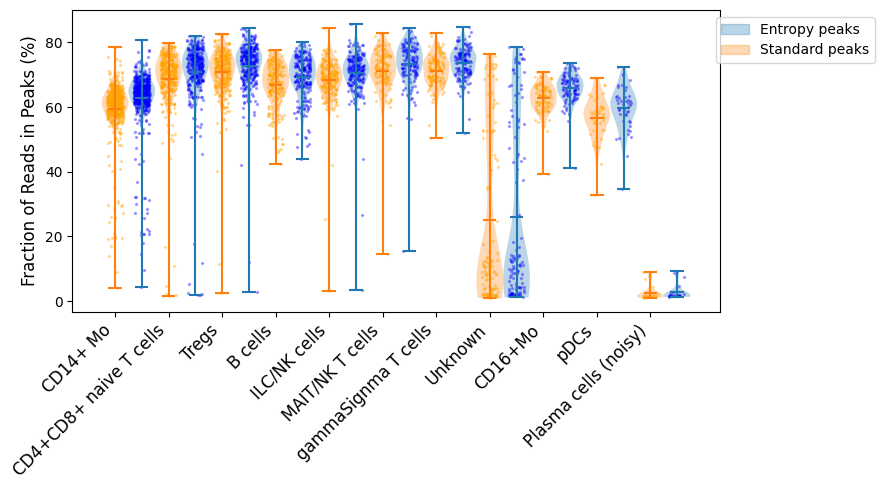

In [14]:
# color_maps = {'0': 'blue', '1': 'orange', '2': 'green', '3': 'red', '4': 'purple',
#               '5': 'brown', '6': 'pink', '7': 'gray', '8': 'olive', '9': 'cyan', '10': 'magenta'}
x_positions = range(11) # also used as RNA cluster ids in string
widths=0.5
labels = []

def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))
    
fig, ax = plt.subplots( figsize=(9, 5))

# Violin plots
standard_peak_data = [h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == str(c), 'standard_peak_FRIP'] for c in x_positions]
entropy_peak_data = [h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == str(c), 'entropy_peak_FRIP'] for c in x_positions]
add_label(ax.violinplot( entropy_peak_data, 
              positions=[x + widths for x in x_positions], widths=widths, vert=True, 
              showmeans=True,), 'Entropy peaks',)
add_label(ax.violinplot( standard_peak_data, 
              positions=x_positions, widths=widths, vert=True, 
              showmeans=True), 'Standard peaks',)

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.15, color='blue'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size

for i, group_data in enumerate(standard_peak_data):
    add_jittered_points(ax, group_data, x_positions[i], color='orange')
for i, group_data in enumerate(entropy_peak_data):
    add_jittered_points(ax, group_data, [x + widths for x in x_positions][i], color='blue')


ax.set_xticks(x_positions)
ax.set_xticklabels([RNAcluster_celltype_map[str(c)] for c in x_positions], rotation=45, ha='right', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)
plt.legend(*zip(*labels), loc='upper right', bbox_to_anchor=(1.25, 1), ncol=1)

plt.tight_layout()


RNA cluster (column pos) 	 ['0 ', '1 ', '2 ', '3 ', '4 ', '5 ', '6 ', '7 ', '8 ', '9 ', '10 ']
Mean Standard peak FRIP: 	,[59.39 68.6  70.77 66.91 68.37 71.23 71.31 25.06 62.69 56.67  2.44]
Mean Entropy peak FRIP: 	,[62.68 70.7  72.84 69.15 70.56 73.38 73.64 26.11 65.99 59.56  2.76]
Median Standard peak FRIP:	,[61.13 70.66 71.96 67.73 69.15 71.8  71.7  10.72 63.2  57.82  1.47]
Median Entropy peak FRIP:	,[64.61 72.84 74.01 69.87 71.38 74.07 74.22 11.32 66.36 60.83  1.72]


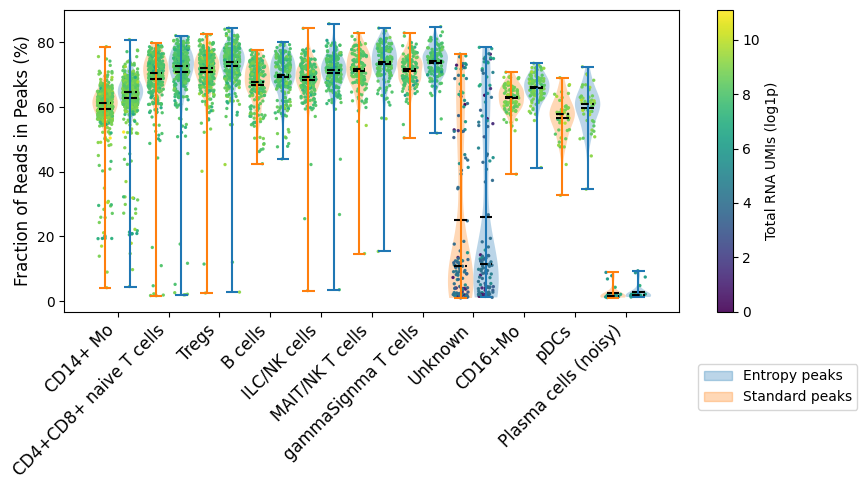

In [15]:
# color_maps = {'0': 'blue', '1': 'orange', '2': 'green', '3': 'red', '4': 'purple',
#               '5': 'brown', '6': 'pink', '7': 'gray', '8': 'olive', '9': 'cyan', '10': 'magenta'}
x_positions = range(11) # also used as RNA cluster ids in string
widths=0.5
pos_adj = 0.25
labels = []

def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))
    
fig, ax = plt.subplots( figsize=(9, 5))

# Violin plots
standard_peak_data = [h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == str(c), 'standard_peak_FRIP'] for c in x_positions]
entropy_peak_data = [h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == str(c), 'entropy_peak_FRIP'] for c in x_positions]
totalUMI_log = [h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == str(c), 'total_RNA_UMI_log'] for c in x_positions]
color_range = (h5_rna.obs['total_RNA_UMI_log'].min(), h5_rna.obs['total_RNA_UMI_log'].max())


mean_standard_peak_FRIP = [np.mean(group) for group in standard_peak_data]
mean_entropy_peak_FRIP = [np.mean(group) for group in entropy_peak_data]
median_standard_peak_FRIP = [np.median(group) for group in standard_peak_data]
median_entropy_peak_FRIP = [np.median(group) for group in entropy_peak_data]

diff_FRIP = [h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == str(c), 'entropy_peak_FRIP'] - \
    h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == str(c), 'standard_peak_FRIP'] \
        for c in x_positions]



v1 = ax.violinplot( entropy_peak_data, 
              positions=np.array(x_positions) + pos_adj, widths=widths, vert=True, 
              showmeans=True, showmedians=True,)
add_label(v1, 'Entropy peaks',)
v2 = ax.violinplot( standard_peak_data, 
              positions=np.array(x_positions) - pos_adj, widths=widths, vert=True, 
              showmeans=True, showmedians=True)
add_label(v2, 'Standard peaks',)


# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, poi_adj, jitter_width, color, color_range):
    # Generate random horizontal jitter
    x_jittered = position + poi_adj+ np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    norm = colors.Normalize(vmin=color_range[0], vmax=color_range[1])
    color_bar = ax.scatter(x_jittered, data_group, c=color, alpha=0.9, s=2, norm=norm) # s controls point size
    return color_bar
  
for i, group_data in enumerate(standard_peak_data):
    cb = add_jittered_points(ax, group_data, x_positions[i], -pos_adj, color=totalUMI_log[i],color_range=color_range, jitter_width=0.15)
for i, group_data in enumerate(entropy_peak_data):
    cb = add_jittered_points(ax, group_data, [x  for x in x_positions][i], pos_adj, color=totalUMI_log[i],color_range=color_range, jitter_width=0.15)

colorbar = fig.colorbar(cb, ax=ax, label='Total RNA UMIs (log1p)')


ax.set_xticks(x_positions)
ax.set_xticklabels([RNAcluster_celltype_map[str(c)] for c in x_positions], rotation=45, ha='right', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)
plt.legend(*zip(*labels), loc='upper left', bbox_to_anchor=(1.02, -0.15), ncol=1)

v1['cmeans'].set_color('black')
v1['cmedians'].set_color('black')
v1['cmedians'].set_linestyle('dashed')
v2['cmeans'].set_color('black')
v2['cmedians'].set_color('black')
v2['cmedians'].set_linestyle('dashed')

plt.tight_layout()



print(f'RNA cluster (column pos) \t {[str(c)+" " for c in x_positions]}')
print(f'Mean Standard peak FRIP: \t,{np.round(mean_standard_peak_FRIP, 2)}')
print(f'Mean Entropy peak FRIP: \t,{np.round(mean_entropy_peak_FRIP, 2)}')
print(f'Median Standard peak FRIP:\t,{np.round(median_standard_peak_FRIP, 2)}')
print(f'Median Entropy peak FRIP:\t,{np.round(median_entropy_peak_FRIP, 2)}')

RNA cluster (column pos) 	 ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
Mean diff FRIP:          	,[3.3  2.1  2.07 2.24 2.19 2.15 2.33 1.05 3.3  2.89 0.31]
Median diff FRIP:        	,[3.41 2.16 2.1  2.28 2.21 2.21 2.37 0.71 3.29 2.87 0.25]


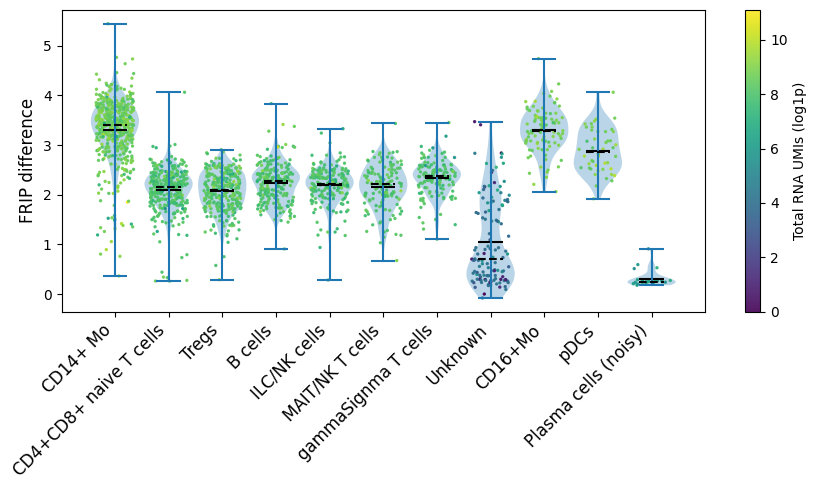

In [16]:
# color_maps = {'0': 'blue', '1': 'orange', '2': 'green', '3': 'red', '4': 'purple',
#               '5': 'brown', '6': 'pink', '7': 'gray', '8': 'olive', '9': 'cyan', '10': 'magenta'}
x_positions = range(11) # also used as RNA cluster ids in string
widths=0.9
pos_adj = 0.0
labels = []

def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))
    
fig, ax = plt.subplots( figsize=(9, 5))

# Violin plots
totalUMI_log = [h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == str(c), 'total_RNA_UMI_log'] for c in x_positions]
color_range = (h5_rna.obs['total_RNA_UMI_log'].min(), h5_rna.obs['total_RNA_UMI_log'].max())


diff_FRIP = [h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == str(c), 'entropy_peak_FRIP'] - \
    h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == str(c), 'standard_peak_FRIP'] \
        for c in x_positions]

mean_diff_FRIP = [np.mean(group) for group in diff_FRIP]
median_diff_FRIP = [np.median(group) for group in diff_FRIP]

v1 = ax.violinplot( diff_FRIP, 
              positions=np.array(x_positions) + pos_adj, widths=widths, vert=True, 
              showmeans=True, showmedians=True,)
add_label(v1, 'diff_FRIP',)



# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, poi_adj, jitter_width, color, color_range):
    # Generate random horizontal jitter
    x_jittered = position + poi_adj+ np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    norm = colors.Normalize(vmin=color_range[0], vmax=color_range[1])
    color_bar = ax.scatter(x_jittered, data_group, c=color, alpha=0.9, s=2, norm=norm) # s controls point size
    return color_bar
  
for i, group_data in enumerate(diff_FRIP):
    cb = add_jittered_points(ax, group_data, x_positions[i], -pos_adj, color=totalUMI_log[i],color_range=color_range, jitter_width=0.35)

colorbar = fig.colorbar(cb, ax=ax, label='Total RNA UMIs (log1p)')


ax.set_xticks(x_positions)
ax.set_xticklabels([RNAcluster_celltype_map[str(c)] for c in x_positions], rotation=45, ha='right', fontsize=12)
ax.set_ylabel('FRIP difference', fontsize=12)
# plt.legend(*zip(*labels), loc='upper right', bbox_to_anchor=(1.25, -0.15), ncol=1)

v1['cmeans'].set_color('black')
v1['cmedians'].set_color('black')
v1['cmedians'].set_linestyle('dashed')

plt.tight_layout()



print(f'RNA cluster (column pos) \t {[str(c)+"" for c in x_positions]}')
print(f'Mean diff FRIP:          \t,{np.round(mean_diff_FRIP, 2)}')
print(f'Median diff FRIP:        \t,{np.round(median_diff_FRIP, 2)}')

In [17]:
h5_rna.obs['standard_peak_FRIP'].describe() , h5_rna.obs['entropy_peak_FRIP'].describe(), (h5_rna.obs['entropy_peak_FRIP'] - h5_rna.obs['standard_peak_FRIP']).describe()

(count    2126.000000
 mean       63.086451
 std        16.083288
 min         0.931004
 25%        60.845213
 50%        66.747551
 75%        72.060476
 max        84.335664
 Name: standard_peak_FRIP, dtype: float64,
 count    2126.000000
 mean       65.498223
 std        16.405211
 min         1.115929
 25%        63.999067
 50%        69.391591
 75%        74.243523
 max        85.780886
 Name: entropy_peak_FRIP, dtype: float64,
 count    2126.000000
 mean        2.411772
 std         0.824635
 min        -0.079428
 25%         1.981299
 50%         2.350209
 75%         2.933284
 max         5.444646
 dtype: float64)

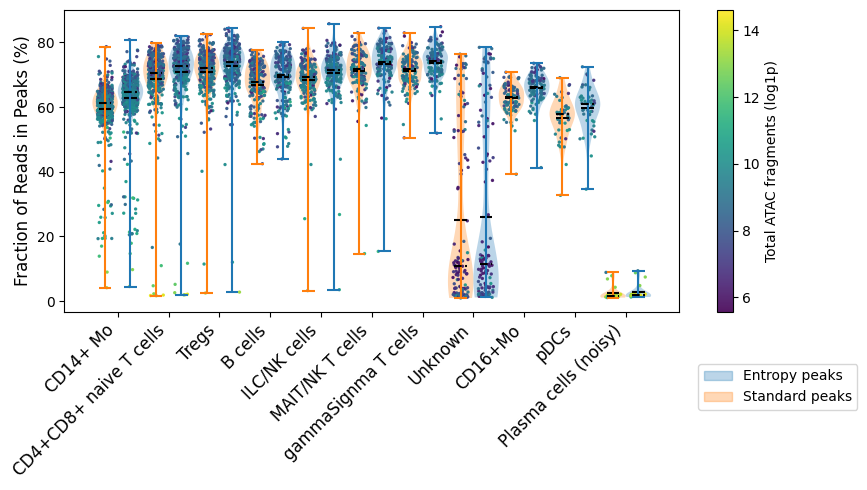

In [18]:
# color_maps = {'0': 'blue', '1': 'orange', '2': 'green', '3': 'red', '4': 'purple',
#               '5': 'brown', '6': 'pink', '7': 'gray', '8': 'olive', '9': 'cyan', '10': 'magenta'}
x_positions = range(11) # also used as RNA cluster ids in string
widths=0.5
pos_adj = 0.25
labels = []

def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))
    
fig, ax = plt.subplots( figsize=(9, 5))

# Violin plots
standard_peak_data = [h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == str(c), 'standard_peak_FRIP'] for c in x_positions]
entropy_peak_data = [h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == str(c), 'entropy_peak_FRIP'] for c in x_positions]
total_atac_fragments = [h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == str(c), 'total_atac_fragments_log1p'] for c in x_positions]
color_range = (h5_rna.obs['total_atac_fragments_log1p'].min(), h5_rna.obs['total_atac_fragments_log1p'].max())

v1 = ax.violinplot( entropy_peak_data, 
              positions=np.array(x_positions) + pos_adj, widths=widths, vert=True, 
              showmeans=True, showmedians=True,)
add_label(v1, 'Entropy peaks',)
v2 = ax.violinplot( standard_peak_data, 
              positions=np.array(x_positions) - pos_adj, widths=widths, vert=True, 
              showmeans=True, showmedians=True)
add_label(v2, 'Standard peaks',)


# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, poi_adj, jitter_width, color, color_range):
    # Generate random horizontal jitter
    x_jittered = position + poi_adj+ np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    norm = colors.Normalize(vmin=color_range[0], vmax=color_range[1])
    color_bar = ax.scatter(x_jittered, data_group, c=color, alpha=0.9, s=2, norm=norm) # s controls point size
    return color_bar
  
for i, group_data in enumerate(standard_peak_data):
    cb = add_jittered_points(ax, group_data, x_positions[i], -pos_adj, color=total_atac_fragments[i],color_range=color_range, jitter_width=0.15)
for i, group_data in enumerate(entropy_peak_data):
    cb = add_jittered_points(ax, group_data, [x  for x in x_positions][i], pos_adj, color=total_atac_fragments[i],color_range=color_range, jitter_width=0.15)

colorbar = fig.colorbar(cb, ax=ax, label='Total ATAC fragments (log1p)')


ax.set_xticks(x_positions)
ax.set_xticklabels([RNAcluster_celltype_map[str(c)] for c in x_positions], rotation=45, ha='right', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)
plt.legend(*zip(*labels), loc='upper left', bbox_to_anchor=(1.02, -0.15), ncol=1)

v1['cmeans'].set_color('black')
v1['cmedians'].set_color('black')
v1['cmedians'].set_linestyle('dashed')
v2['cmeans'].set_color('black')
v2['cmedians'].set_color('black')
v2['cmedians'].set_linestyle('dashed')

plt.tight_layout()

In [19]:
RNAcluster_celltype_map

{'0': 'CD14+ Mo',
 '1': 'CD4+CD8+ naive T cells',
 '2': 'Tregs',
 '3': 'B cells',
 '4': 'ILC/NK cells',
 '5': 'MAIT/NK T cells',
 '6': 'gammaSignma T cells',
 '7': 'Unknown',
 '8': 'CD16+Mo',
 '9': 'pDCs',
 '10': 'Plasma cells (noisy)'}

RNA_cluster: range(0, 11)
median_entropy: [-0.632 -0.807 -0.814 -0.845 -0.746 -0.811 -0.753 -0.957 -0.729 -0.605
  0.081]
mean_entropy: [-0.64188898 -0.80869034 -0.8251243  -0.84326913 -0.75797377 -0.83800935
 -0.77219718 -0.90289619 -0.74804191 -0.63186229  0.04091958]


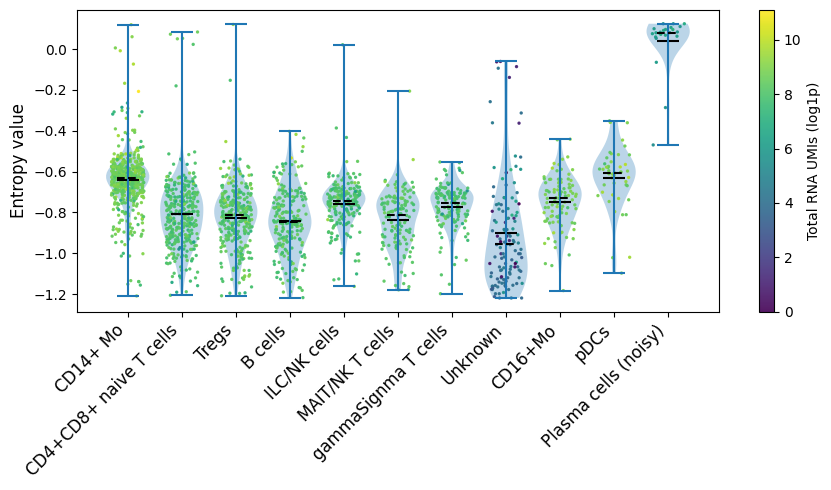

In [20]:
x_positions = range(11)  #also used as standard_peak_cluster id in string
widths=0.8
labels = []
    
fig, ax = plt.subplots( figsize=(9, 5))

# Violin plots
entropy_value = [h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == str(c), 'Entropy_log'] for c in x_positions]
totalUMI_log = [h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == str(c), 'total_RNA_UMI_log'] for c in x_positions]
median_entropy = [np.median(a) for a in entropy_value] 
mean_entropy = [np.mean(a) for a in entropy_value]
color_range = (h5_rna.obs['total_RNA_UMI_log'].min(), h5_rna.obs['total_RNA_UMI_log'].max())
vp = ax.violinplot( entropy_value, 
              positions=x_positions, widths=widths, vert=True, 
              showmedians=True, showmeans=True)

np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width, color, color_range):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    norm = colors.Normalize(vmin=color_range[0], vmax=color_range[1])
    color_bar = ax.scatter(x_jittered, data_group, c=color, alpha=0.9, s=2, norm=norm) # s controls point size
    return color_bar
  
for i, group_data in enumerate(entropy_value):
    cb = add_jittered_points(ax, group_data, x_positions[i], color=totalUMI_log[i],color_range=color_range, jitter_width=0.3)


ax.set_xticks(x_positions)
ax.set_xticklabels([RNAcluster_celltype_map[str(c)] for c in x_positions], rotation=45, ha='right', fontsize=12)
ax.set_ylabel('Entropy value', fontsize=12)

cbar = fig.colorbar(cb, ax=ax)
cbar.set_label('Total RNA UMIs (log1p)') # Set the label for the colorbar

vp['cmeans'].set_color('black')
vp['cmedians'].set_color('black')
vp['cmedians'].set_linestyles('dashed')

plt.tight_layout()


print (f'RNA_cluster: {x_positions}')
print(f'median_entropy: {np.round(median_entropy, 3)}')
print(f'mean_entropy: {np.round(mean_entropy, 23)}')

RNA_cluster: range(0, 11)
median_entropy: [-0.632 -0.807 -0.814 -0.845 -0.746 -0.811 -0.753 -0.957 -0.729 -0.605
  0.081]
mean_entropy: [-0.64188898 -0.80869034 -0.8251243  -0.84326913 -0.75797377 -0.83800935
 -0.77219718 -0.90289619 -0.74804191 -0.63186229  0.04091958]


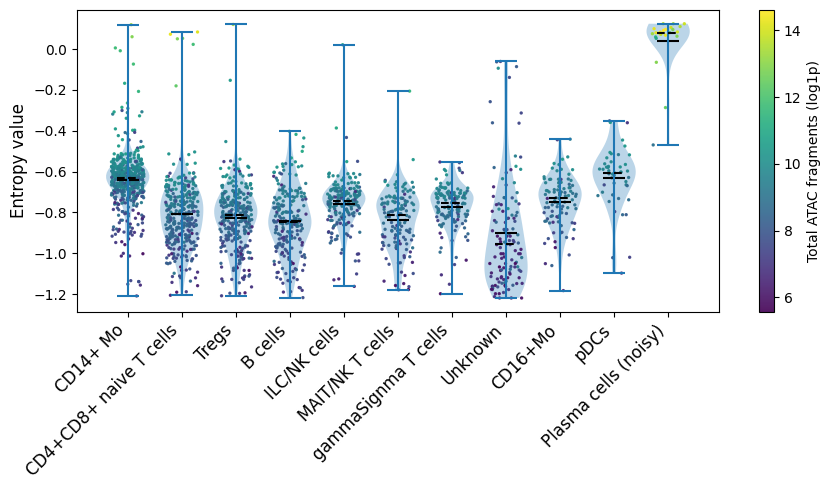

In [21]:
x_positions = range(11)  #also used as RNA_cluster id in string
widths=0.8
labels = []
    
fig, ax = plt.subplots( figsize=(9, 5))

# Violin plots
entropy_value = [h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == str(c), 'Entropy_log'] for c in x_positions]
total_atac_fragments = [h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == str(c), 'total_atac_fragments_log1p'] for c in x_positions]
median_entropy = [np.median(a) for a in entropy_value] 
mean_entropy = [np.mean(a) for a in entropy_value]
color_range = (h5_rna.obs['total_atac_fragments_log1p'].min(), h5_rna.obs['total_atac_fragments_log1p'].max())
vp = ax.violinplot( entropy_value, 
              positions=x_positions, widths=widths, vert=True, 
              showmedians=True, showmeans=True)

np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width, color, color_range):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    norm = colors.Normalize(vmin=color_range[0], vmax=color_range[1])
    color_bar = ax.scatter(x_jittered, data_group, c=color, alpha=0.9, s=2, norm=norm) # s controls point size
    return color_bar
  
for i, group_data in enumerate(entropy_value):
    cb = add_jittered_points(ax, group_data, x_positions[i], color=total_atac_fragments[i],color_range=color_range, jitter_width=0.3)


ax.set_xticks(x_positions)
ax.set_xticklabels([RNAcluster_celltype_map[str(c)] for c in x_positions], rotation=45, ha='right', fontsize=12)
ax.set_ylabel('Entropy value', fontsize=12)

cbar = fig.colorbar(cb, ax=ax)
cbar.set_label('Total ATAC fragments (log1p)') # Set the label for the colorbar

vp['cmeans'].set_color('black')
vp['cmedians'].set_color('black')
vp['cmedians'].set_linestyles('dashed')


plt.tight_layout()


print (f'RNA_cluster: {x_positions}')
print(f'median_entropy: {np.round(median_entropy, 3)}')
print(f'mean_entropy: {np.round(mean_entropy, 23)}')

## Plot to see consistency between atac space and rna space 

In [22]:
if 'clusters_peakvi_entropy' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_entropy', axis=1, inplace=True)
if 'clusters_peakvi_highres_entropy' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_highres_entropy', axis=1, inplace=True)

if 'clusters_peakvi_standard' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_standard', axis=1, inplace=True)
if 'clusters_peakvi_highres_standard' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_highres_standard', axis=1, inplace=True)
    

h5_rna.obs = h5_rna.obs.merge(entropy_peak.obs[['clusters_peakvi_entropy', 'clusters_peakvi_highres_entropy']], left_on='atac_bc', right_index=True, how='left')
h5_rna.obs = h5_rna.obs.merge(peak.obs[['clusters_peakvi_standard', 'clusters_peakvi_highres_standard']], left_on='atac_bc', right_index=True, how='left')

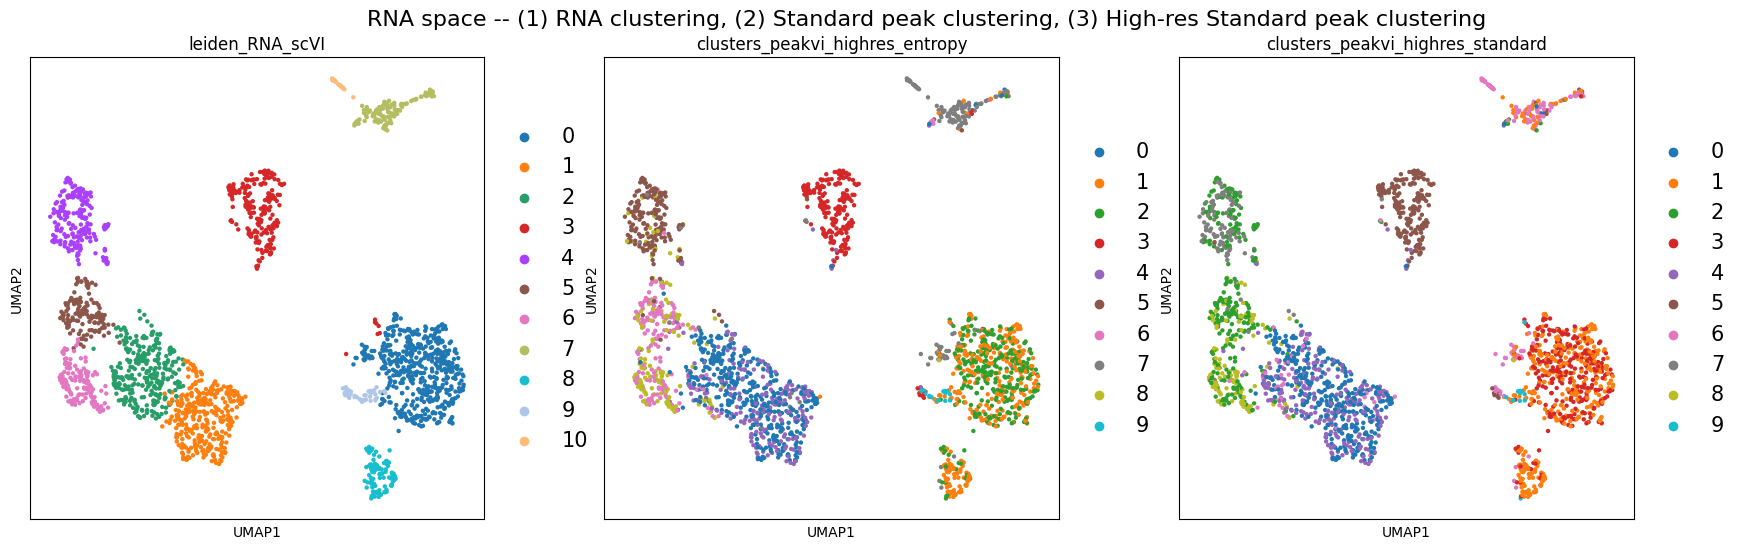

In [23]:
with plt.rc_context({'figure.figsize': (6, 6)}):
    axes = sc.pl.umap(h5_rna, color=['leiden_RNA_scVI', 'clusters_peakvi_highres_entropy', 'clusters_peakvi_highres_standard'], wspace=0.15, ncols=3, size=40, legend_fontsize=15, show=False)
    plt.suptitle('RNA space -- (1) RNA clustering, (2) Standard peak clustering, (3) High-res Standard peak clustering', fontsize=16)
    
    plt.show()

###  Reorder cluster-order in entropy_peak to match for color in standard_peak

In [24]:
# Reference is 'clusters_peakvi_highres_standard'
relate_labels = h5_rna.obs.groupby(['clusters_peakvi_highres_standard', 'clusters_peakvi_highres_entropy']).size().unstack(fill_value=0)
ordered_col, remained_col = order_m(relate_labels.values)

# # Now map the best matching clusters
h5_rna.obs['reorder_clusters_peakvi_highres_entropy'] = h5_rna.obs['clusters_peakvi_highres_entropy'].cat.reorder_categories([str(i) for i in ordered_col+remained_col], ordered=False)

h5_rna.obs.groupby(['clusters_peakvi_highres_standard', 'reorder_clusters_peakvi_highres_entropy']).size().unstack(fill_value=0)


/tmp/ipykernel_618038/1259035287.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  relate_labels = h5_rna.obs.groupby(['clusters_peakvi_highres_standard', 'clusters_peakvi_highres_entropy']).size().unstack(fill_value=0)
/tmp/ipykernel_618038/1259035287.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_rna.obs.groupby(['clusters_peakvi_highres_standard', 'reorder_clusters_peakvi_highres_entropy']).size().unstack(fill_value=0)


reorder_clusters_peakvi_highres_entropy,0,1,6,2,4,3,7,5,8,9
clusters_peakvi_highres_standard,,,,,,,,,,
0,353,1,3,0,12,0,3,0,0,0
1,0,303,0,24,0,0,34,0,0,0
2,7,0,158,0,3,0,5,102,0,0
3,0,7,0,260,0,0,5,0,0,0
4,30,0,1,0,191,0,0,0,7,0
5,1,0,0,0,0,210,3,0,0,0
6,20,3,10,0,1,1,107,0,0,6
7,0,0,1,0,0,0,1,93,28,0
8,0,0,0,0,3,0,0,1,112,0


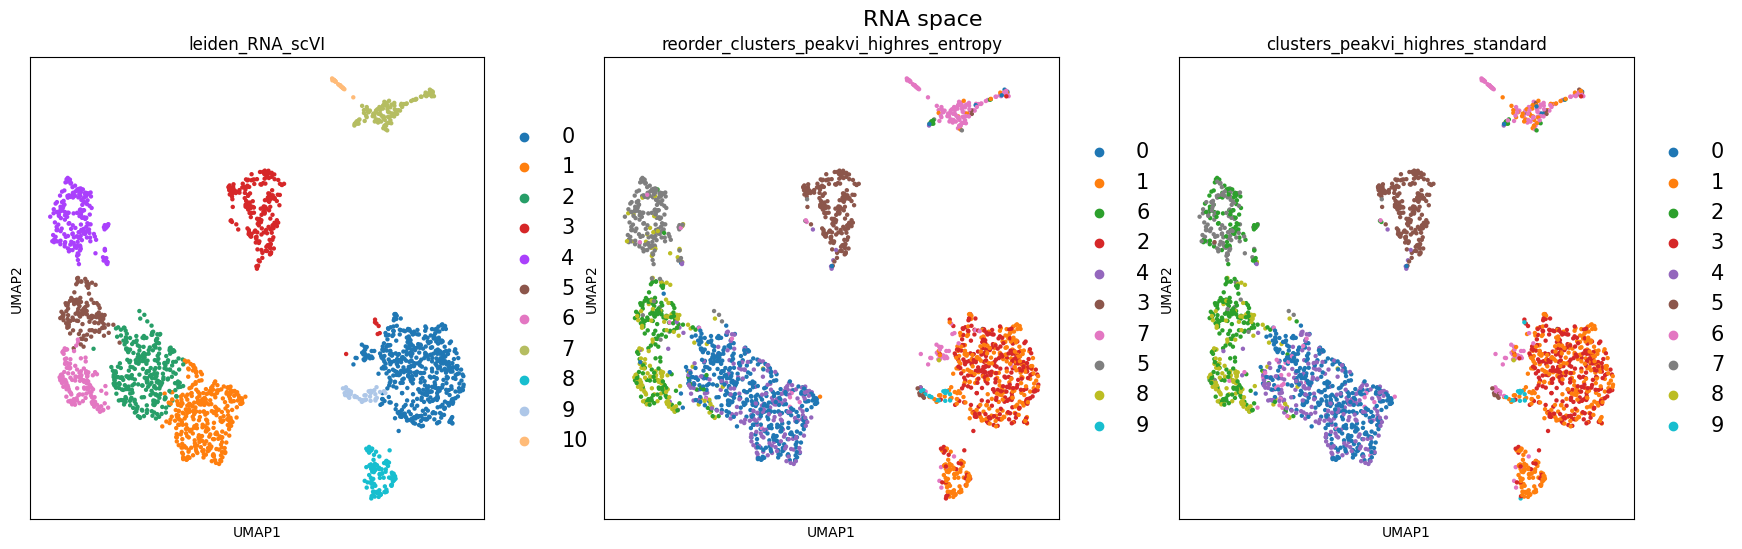

In [25]:
with plt.rc_context({'figure.figsize': (6, 6)}):
    axes = sc.pl.umap(h5_rna, color=['leiden_RNA_scVI', 'reorder_clusters_peakvi_highres_entropy', \
        'clusters_peakvi_highres_standard', \
        ], wspace=0.15, ncols=3, size=40, legend_fontsize=15, show=False)
    plt.suptitle('RNA space ', fontsize=16)
    
    plt.show()

Entropy_peak_cluster: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
median_entropy: [-0.879 -0.708 -0.61  -0.855 -0.72  -0.756 -0.851 -0.721 -0.705 -0.584
    inf    inf    inf]
mean_entropy: [-0.642 -0.809 -0.825 -0.843 -0.758 -0.838 -0.772 -0.903 -0.748 -0.632
  0.041]


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/numpy/core/function_base.py:139: RuntimeWarning: invalid value encountered in scalar subtract
  delta = stop - start


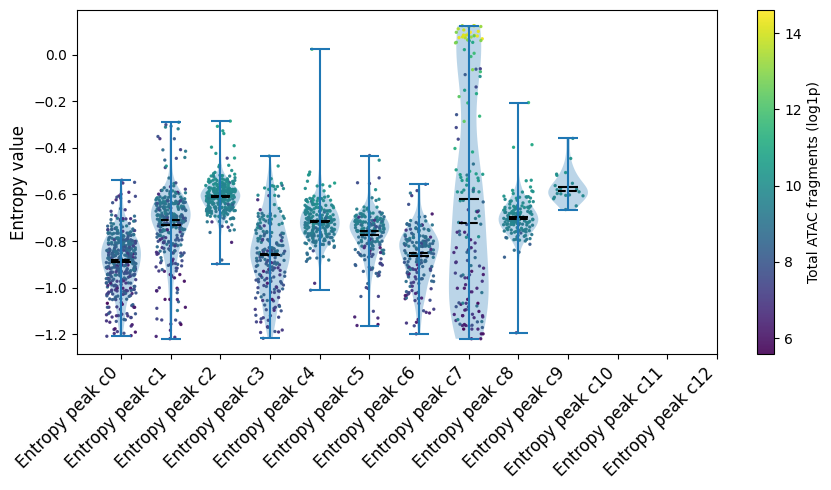

In [26]:

x_positions = range(13)  #also used as RNA_cluster id in string
widths=0.8
labels = []
    
fig, ax = plt.subplots( figsize=(9, 5))

# Violin plots
entropy_value = [h5_rna.obs.loc[h5_rna.obs['reorder_clusters_peakvi_highres_entropy'] == str(c), 'Entropy_log'] for c in x_positions]
total_atac_fragments = [h5_rna.obs.loc[h5_rna.obs['reorder_clusters_peakvi_highres_entropy'] == str(c), 'total_atac_fragments_log1p'] for c in x_positions]
color_range = (h5_rna.obs['total_atac_fragments_log1p'].min(), h5_rna.obs['total_atac_fragments_log1p'].max())
for i, v in enumerate(entropy_value):
    if len(v) ==0:
        entropy_value[i] = np.array([np.inf])  # to avoid error in violin plot when no data point exists
        total_atac_fragments[i] = np.array([np.inf])
        
median_entropy = [np.median(a) for a in entropy_value]
color_range = (h5_rna.obs['total_atac_fragments_log1p'].min(), h5_rna.obs['total_atac_fragments_log1p'].max())
vp = ax.violinplot( entropy_value, 
              positions=x_positions, widths=widths, vert=True, 
              showmedians=True, showmeans=True)

np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width, color, color_range):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    norm = colors.Normalize(vmin=color_range[0], vmax=color_range[1])
    color_bar = ax.scatter(x_jittered, data_group, c=color, alpha=0.9, s=2, norm=norm) # s controls point size
    return color_bar
  
for i, group_data in enumerate(entropy_value):
    cb = add_jittered_points(ax, group_data, x_positions[i], color=total_atac_fragments[i],color_range=color_range, jitter_width=0.3)


ax.set_xticks(x_positions)
ax.set_xticklabels(['Entropy peak c' + str(c) for c in x_positions], rotation=45, ha='right', fontsize=12)
ax.set_ylabel('Entropy value', fontsize=12)

cbar = fig.colorbar(cb, ax=ax)
cbar.set_label('Total ATAC fragments (log1p)') # Set the label for the colorbar

vp['cmeans'].set_color('black')
vp['cmedians'].set_color('black')
vp['cmedians'].set_linestyles('dashed')


plt.tight_layout()


print (f'Entropy_peak_cluster: {list(x_positions )}')
print(f'median_entropy: {np.round(median_entropy, 3)}')
print(f'mean_entropy: {np.round(mean_entropy, 3)}')

# Load AMULET doublet detection results

In [27]:

# load AMULET doublet detection results
AMULET_doublet_file = os.path.join(entropy_dir, '_UnionBC_fragments/AMULET_output/MultipletProbabilities.txt')
AMULET_doublet_df = pd.read_csv(AMULET_doublet_file, sep='\t', index_col=0)
AMULET_doublet_df['atac_bc'] = AMULET_doublet_df.index.map(lambda x: x.split('-1')[0])
AMULET_doublet_df.reset_index(inplace=True, drop=False)
AMULET_doublet_df.set_index('atac_bc', inplace=True)
AMULET_doublet_df = AMULET_doublet_df.rename(columns={'p-value': 'AMULET_pvalue', 'q-value': 'AMULET_qvalue'}, inplace=False)


In [28]:
AMULET_doublet_df.head()

,cell_id,barcode,AMULET_pvalue,AMULET_qvalue
atac_bc,,,,
AAACAAGCAAGTTAGT,AAACAAGCAAGTTAGT-1,AAACAAGCAAGTTAGT-1,1.0,1.0
AAACAAGCATTTCTTC,AAACAAGCATTTCTTC-1,AAACAAGCATTTCTTC-1,1.0,1.0
AAACCGCCAACGGTAC,AAACCGCCAACGGTAC-1,AAACCGCCAACGGTAC-1,1.0,1.0
AAACCGCCAGAAACCC,AAACCGCCAGAAACCC-1,AAACCGCCAGAAACCC-1,1.0,1.0
AAACGAACACCTGTAT,AAACGAACACCTGTAT-1,AAACGAACACCTGTAT-1,1.0,1.0


In [29]:
if 'AMULET_qvalue' not in h5_rna.obs.columns:
    h5_rna.obs = h5_rna.obs.merge(AMULET_doublet_df[[ 'AMULET_qvalue']], left_on='atac_bc', right_index=True, how='left')
h5_rna.obs['AMULET_doublet'] = h5_rna.obs['AMULET_qvalue'] < 0.05

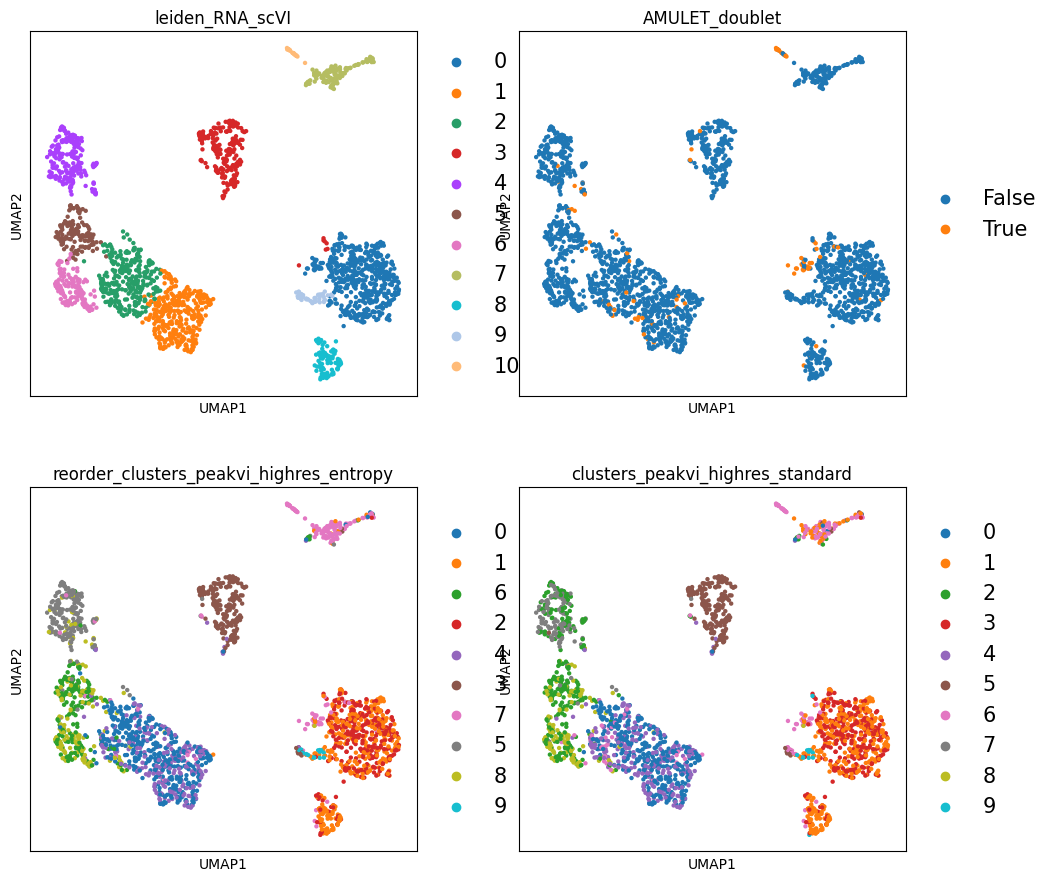

In [30]:
with plt.rc_context({'figure.figsize': (5, 5)}):
    sc.pl.umap(h5_rna, color=['leiden_RNA_scVI', 'AMULET_doublet', 
                'reorder_clusters_peakvi_highres_entropy', 'clusters_peakvi_highres_standard'],
               wspace=0.15, ncols=2, size=40, legend_fontsize=15, show=False)

## Increase resolution on ATAC clustering

In [31]:
atac_resolution = 0.5
sc.tl.leiden(entropy_peak, key_added='clusters_peakvi_higherres_entropy', resolution=atac_resolution+ 0.1)
sc.tl.leiden(peak, key_added='clusters_peakvi_higherres_standard', resolution=atac_resolution + 0.1)

In [32]:
if 'clusters_peakvi_higherres_entropy' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_higherres_entropy', axis=1, inplace=True)

if 'clusters_peakvi_higherres_standard' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_higherres_standard', axis=1, inplace=True)
    

h5_rna.obs = h5_rna.obs.merge(entropy_peak.obs[[ 'clusters_peakvi_higherres_entropy']], left_on='atac_bc', right_index=True, how='left')
h5_rna.obs = h5_rna.obs.merge(peak.obs[[ 'clusters_peakvi_higherres_standard']], left_on='atac_bc', right_index=True, how='left')

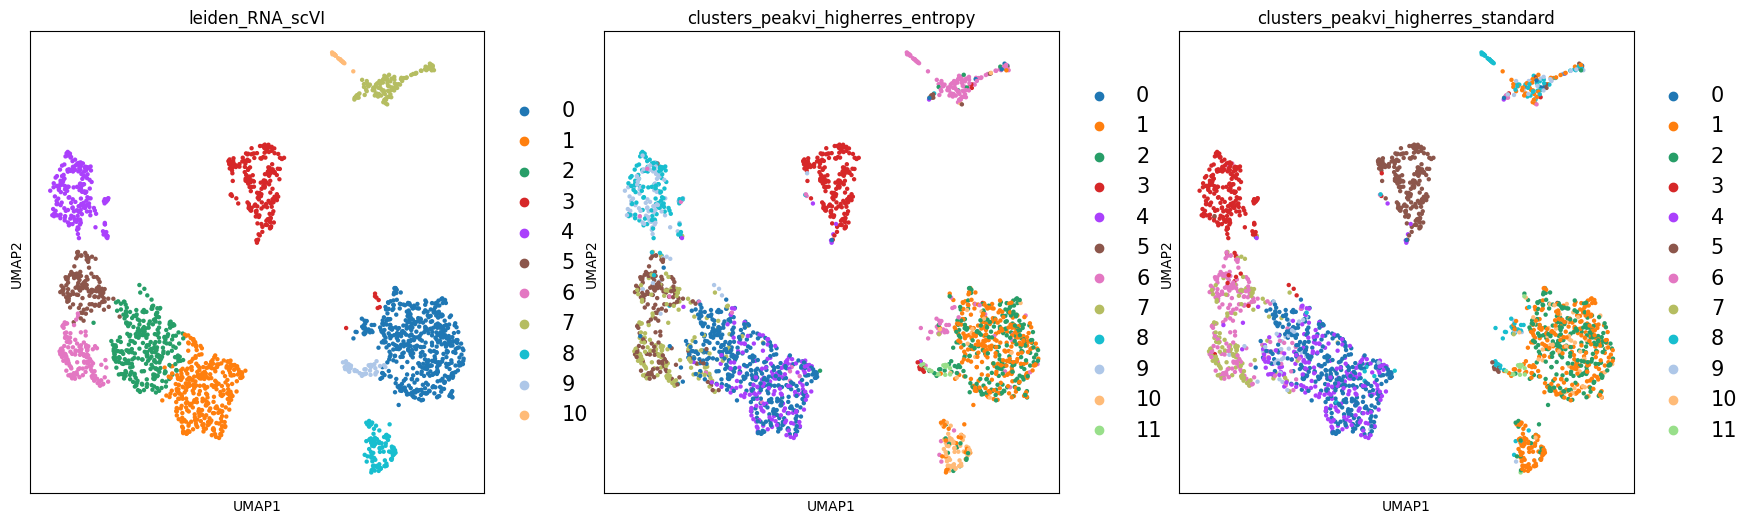

In [33]:
with plt.rc_context({'figure.figsize': (6, 6)}):
    sc.pl.umap(h5_rna, color=['leiden_RNA_scVI', 'clusters_peakvi_higherres_entropy', 'clusters_peakvi_higherres_standard'], wspace=0.15, ncols=3, size=40, legend_fontsize=15, show=False)


/tmp/ipykernel_618038/4271070450.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  correspondance_entropy = h5_rna.obs.groupby(['celltype', 'clusters_peakvi_higherres_entropy']).size().unstack()
/tmp/ipykernel_618038/4271070450.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  correspondance_standard = h5_rna.obs.groupby(['celltype', 'clusters_peakvi_higherres_standard']).size().unstack()


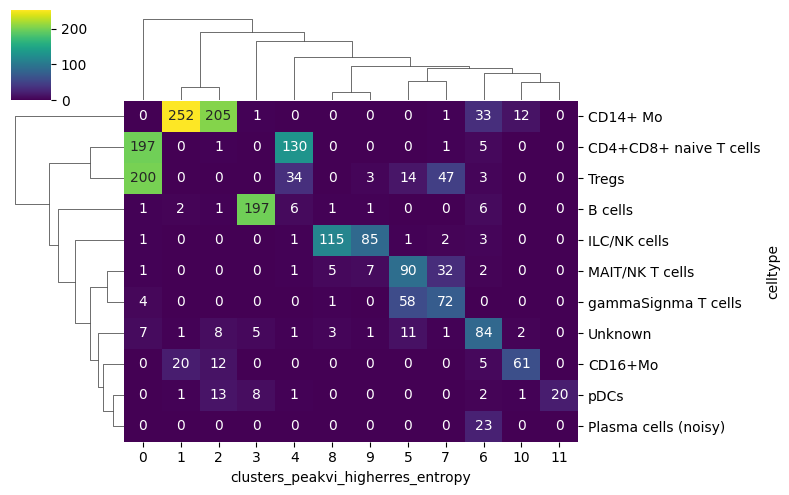

In [34]:
correspondance_entropy = h5_rna.obs.groupby(['celltype', 'clusters_peakvi_higherres_entropy']).size().unstack()
correspondance_standard = h5_rna.obs.groupby(['celltype', 'clusters_peakvi_higherres_standard']).size().unstack()

sns.clustermap(correspondance_entropy, cmap='viridis', figsize=(8, 5), annot=True, fmt='d', col_cluster=True)

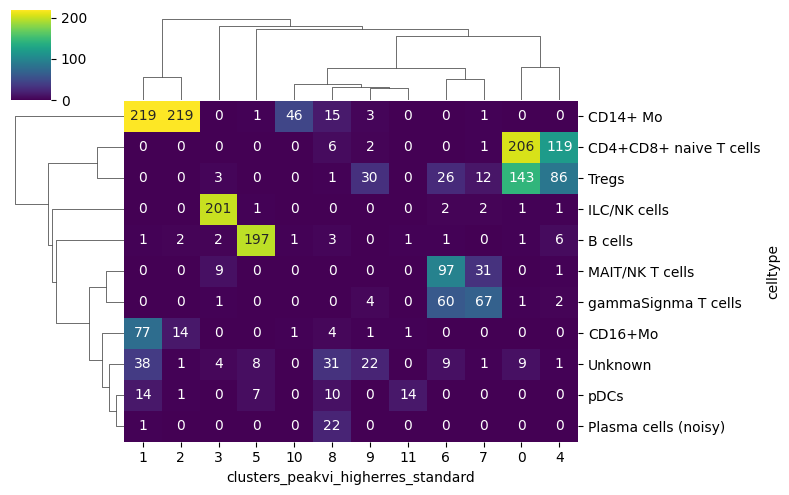

In [35]:
sns.clustermap(correspondance_standard, cmap='viridis', figsize=(8, 5), annot=True, fmt='d', col_cluster=True)

In [36]:
# Reference is 'clusters_peakvi_higherres_standard'
relate_labels2 = h5_rna.obs.groupby(['clusters_peakvi_higherres_standard', 'clusters_peakvi_higherres_entropy']).size().unstack(fill_value=0)
ordered_col, remained_col = order_m(relate_labels2.values)

# # Now map the best matching clusters
h5_rna.obs['reorder_clusters_peakvi_higherres_entropy'] = h5_rna.obs['clusters_peakvi_higherres_entropy'].cat.reorder_categories([str(i) for i in ordered_col+remained_col], ordered=False)
h5_rna.obs.groupby(['clusters_peakvi_higherres_standard', 'reorder_clusters_peakvi_higherres_entropy']).size().unstack(fill_value=0)

/tmp/ipykernel_618038/2470988926.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  relate_labels2 = h5_rna.obs.groupby(['clusters_peakvi_higherres_standard', 'clusters_peakvi_higherres_entropy']).size().unstack(fill_value=0)
/tmp/ipykernel_618038/2470988926.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_rna.obs.groupby(['clusters_peakvi_higherres_standard', 'reorder_clusters_peakvi_higherres_entropy']).size().unstack(fill_value=0)


reorder_clusters_peakvi_higherres_entropy,0,2,1,8,4,3,5,7,6,9,10,11
clusters_peakvi_higherres_standard,,,,,,,,,,,,
0,342,1,0,0,12,0,3,0,3,0,0,0
1,0,225,15,0,0,0,0,0,34,0,76,0
2,0,11,226,0,0,0,0,0,0,0,0,0
3,0,0,0,118,0,0,1,4,5,92,0,0
4,19,0,0,0,161,0,0,36,0,0,0,0
5,1,0,0,0,0,210,0,0,3,0,0,0
6,21,0,0,7,0,0,160,5,1,1,0,0
7,0,0,0,0,0,0,0,111,0,4,0,0
8,0,2,0,0,1,1,0,0,82,0,0,6


# Take a closer look at Entropy Cluster 6 

## Take a closer look at RNAcluster 7 particularly

In [ ]:
rna_c7_h5 = h5_rna[(h5_rna.obs['leiden_RNA_scVI'] == '7') | (h5_rna.obs['leiden_RNA_scVI'] == '10'), :].copy()


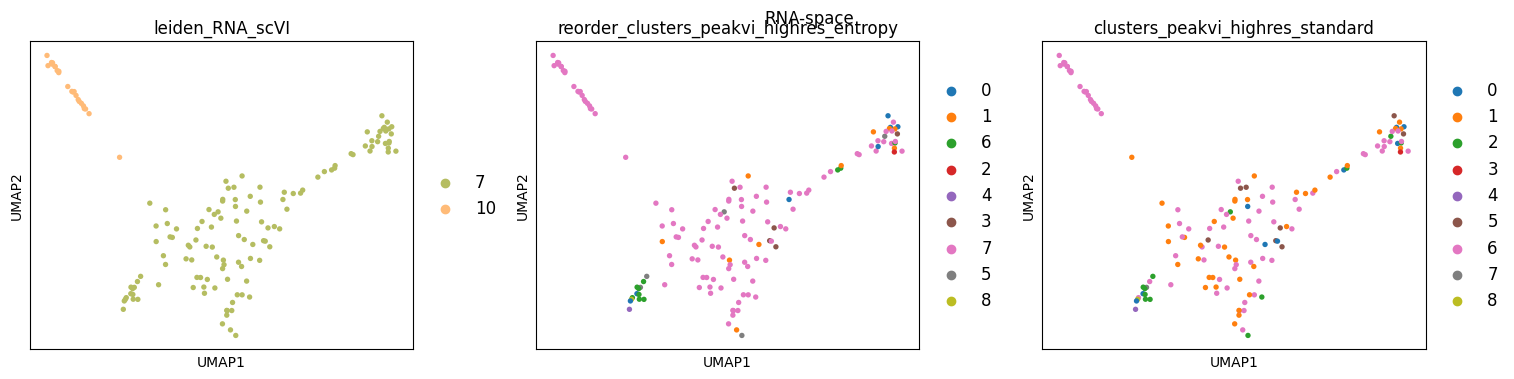

In [ ]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(rna_c7_h5, color=['leiden_RNA_scVI', 'reorder_clusters_peakvi_highres_entropy', 'clusters_peakvi_highres_standard'], wspace=0.2, ncols=3, size=60, legend_fontsize=12, show=False)
    #plt.suptitle('RNA space -- (1) RNA clustering, (2) Standard peak clustering, (3) High-res Standard peak clustering', fontsize=12)
    plt.suptitle('RNA-space')
    plt.show()

In [ ]:
rna_c7_h5.obs.groupby(['leiden_RNA_scVI', 'reorder_clusters_peakvi_highres_entropy']).size().unstack(fill_value=0)

/tmp/ipykernel_577536/1852828971.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rna_c7_h5.obs.groupby(['leiden_RNA_scVI', 'reorder_clusters_peakvi_highres_entropy']).size().unstack(fill_value=0)


reorder_clusters_peakvi_highres_entropy,0,1,6,2,4,3,7,5,8
leiden_RNA_scVI,,,,,,,,,
7,7,10,10,1,1,5,84,5,1
10,0,0,0,0,0,0,23,0,0


/tmp/ipykernel_577536/1792958211.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_per_cluster = rna_c7_h5.obs.groupby('reorder_clusters_peakvi_highres_entropy').size()


(0.0, 113.0)

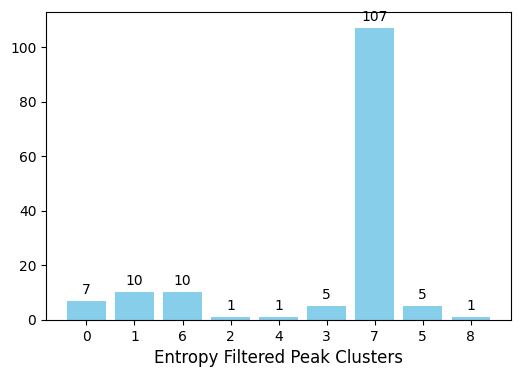

In [ ]:
counts_per_cluster = rna_c7_h5.obs.groupby('reorder_clusters_peakvi_highres_entropy').size()

fig, ax = plt.subplots(figsize=(6,4))

p=ax.bar(counts_per_cluster.index, counts_per_cluster.values, color='skyblue')
ax.bar_label(p, padding=3, fontsize=10)

ax.set_xlabel('Entropy Filtered Peak Clusters', fontsize=12)
ax.set_ylim(0, counts_per_cluster.values.max() + 6)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/numpy/core/function_base.py:139: RuntimeWarning: invalid value encountered in scalar subtract
  delta = stop - start


Entropy_peak_cluster: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
median_entropy: [-0.956 -1.067 -0.524 -0.981 -0.635 -0.829 -0.899 -0.905 -0.745    inf
    inf    inf    inf]
mean_entropy: [-0.642 -0.809 -0.825 -0.843 -0.758 -0.838 -0.772 -0.903 -0.748 -0.632
  0.041]


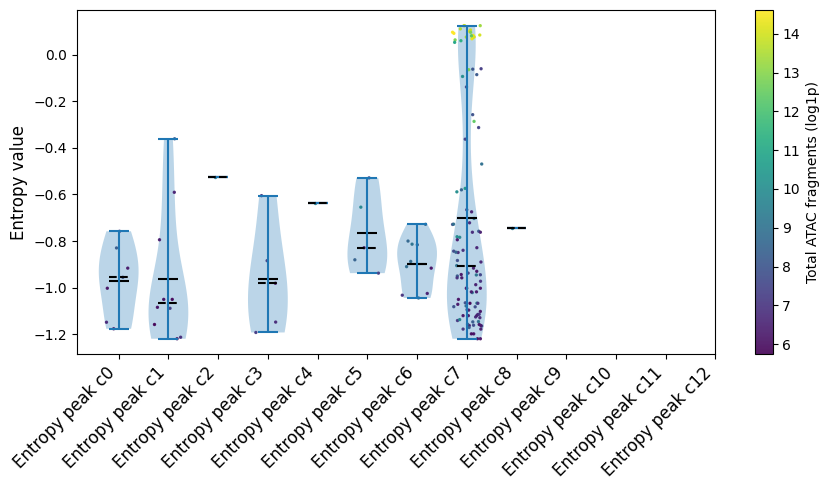

In [ ]:

x_positions = range(13)  #also used as RNA_cluster id in string
widths=0.8
labels = []
    
fig, ax = plt.subplots( figsize=(9, 5))

# Violin plots
entropy_value = [rna_c7_h5.obs.loc[rna_c7_h5.obs['reorder_clusters_peakvi_highres_entropy'] == str(c), 'Entropy_log'] for c in x_positions]
total_atac_fragments = [rna_c7_h5.obs.loc[rna_c7_h5.obs['reorder_clusters_peakvi_highres_entropy'] == str(c), 'total_atac_fragments_log1p'] for c in x_positions]
color_range = (h5_rna.obs['total_atac_fragments_log1p'].min(), h5_rna.obs['total_atac_fragments_log1p'].max())
for i, v in enumerate(entropy_value):
    if len(v) ==0:
        entropy_value[i] = np.array([np.inf])  # to avoid error in violin plot when no data point exists
        total_atac_fragments[i] = np.array([np.inf])
        
median_entropy = [np.median(a) for a in entropy_value]
color_range = (rna_c7_h5.obs['total_atac_fragments_log1p'].min(), rna_c7_h5.obs['total_atac_fragments_log1p'].max())
vp = ax.violinplot( entropy_value, 
              positions=x_positions, widths=widths, vert=True, 
              showmedians=True, showmeans=True)

np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width, color, color_range):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    norm = colors.Normalize(vmin=color_range[0], vmax=color_range[1])
    color_bar = ax.scatter(x_jittered, data_group, c=color, alpha=0.9, s=2, norm=norm) # s controls point size
    return color_bar
  
for i, group_data in enumerate(entropy_value):
    cb = add_jittered_points(ax, group_data, x_positions[i], color=total_atac_fragments[i],color_range=color_range, jitter_width=0.3)


ax.set_xticks(x_positions)
ax.set_xticklabels(['Entropy peak c' + str(c) for c in x_positions], rotation=45, ha='right', fontsize=12)
ax.set_ylabel('Entropy value', fontsize=12)

cbar = fig.colorbar(cb, ax=ax)
cbar.set_label('Total ATAC fragments (log1p)') # Set the label for the colorbar

vp['cmeans'].set_color('black')
vp['cmedians'].set_color('black')
vp['cmedians'].set_linestyles('dashed')


plt.tight_layout()


print (f'Entropy_peak_cluster: {list(x_positions )}')
print(f'median_entropy: {np.round(median_entropy, 3)}')
print(f'mean_entropy: {np.round(mean_entropy, 3)}')

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/numpy/core/function_base.py:139: RuntimeWarning: invalid value encountered in scalar subtract
  delta = stop - start


Entropy_peak_cluster: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
median_entropy: [-0.956 -1.067 -0.524 -0.981 -0.635 -0.829 -0.899 -0.905 -0.745    inf
    inf    inf    inf]
mean_entropy: [-0.642 -0.809 -0.825 -0.843 -0.758 -0.838 -0.772 -0.903 -0.748 -0.632
  0.041]


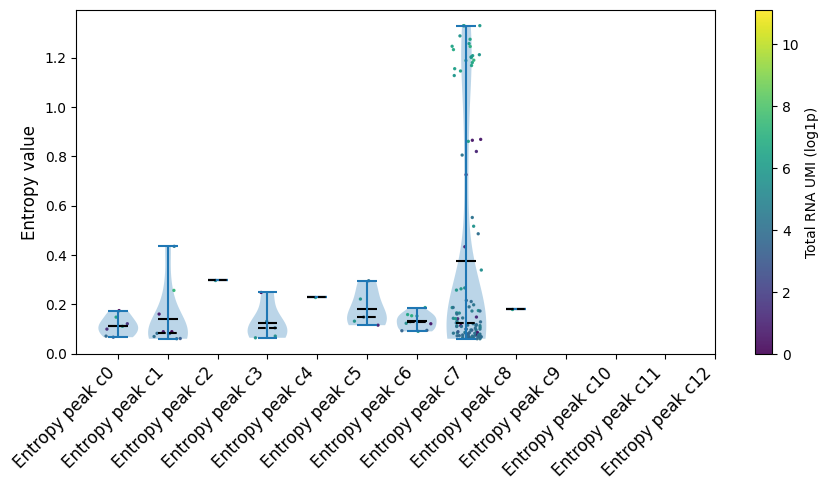

In [ ]:

x_positions = range(13)  #also used as RNA_cluster id in string
widths=0.8
labels = []
    
fig, ax = plt.subplots( figsize=(9, 5))

# Violin plots
entropy_value = [rna_c7_h5.obs.loc[rna_c7_h5.obs['reorder_clusters_peakvi_highres_entropy'] == str(c), 'Entropy'] for c in x_positions]
total_RNA_umi = [rna_c7_h5.obs.loc[rna_c7_h5.obs['reorder_clusters_peakvi_highres_entropy'] == str(c), 'total_RNA_UMI_log'] for c in x_positions]
color_range = (h5_rna.obs['total_RNA_UMI_log'].min(), h5_rna.obs['total_RNA_UMI_log'].max())
for i, v in enumerate(entropy_value):
    if len(v) ==0:
        entropy_value[i] = np.array([np.inf])  # to avoid error in violin plot when no data point exists
        total_RNA_umi[i] = np.array([np.inf])
        

vp = ax.violinplot( entropy_value, 
              positions=x_positions, widths=widths, vert=True, 
              showmedians=True, showmeans=True)

np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width, color, color_range):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    norm = colors.Normalize(vmin=color_range[0], vmax=color_range[1])
    color_bar = ax.scatter(x_jittered, data_group, c=color, alpha=0.9, s=2, norm=norm) # s controls point size
    return color_bar
  
for i, group_data in enumerate(entropy_value):
    cb = add_jittered_points(ax, group_data, x_positions[i], color=total_RNA_umi[i],color_range=color_range, jitter_width=0.3)


ax.set_xticks(x_positions)
ax.set_xticklabels(['Entropy peak c' + str(c) for c in x_positions], rotation=45, ha='right', fontsize=12)
ax.set_ylabel('Entropy value', fontsize=12)

cbar = fig.colorbar(cb, ax=ax)
cbar.set_label('Total RNA UMI (log1p)') # Set the label for the colorbar

vp['cmeans'].set_color('black')
vp['cmedians'].set_color('black')
vp['cmedians'].set_linestyles('dashed')


plt.tight_layout()


print (f'Entropy_peak_cluster: {list(x_positions )}')
print(f'median_entropy: {np.round(median_entropy, 3)}')
print(f'mean_entropy: {np.round(mean_entropy, 3)}')

# Load peak info -- (rediscovered, newly-discovred, or lost labels)

In [ ]:
peak_comparison_dir = os.path.join(entropy_dir, 'peaks_comparison')
lost_peaks_anno_file = os.path.join(peak_comparison_dir, 'lost_peaks.bed')
newly_discovered_peaks_anno_file = os.path.join(peak_comparison_dir, 'newly_discovered_peaks.bed')
recovered_peaks_anno_file = os.path.join(peak_comparison_dir, 'recovered_peaks.bed')

lost_peaks_anno = pd.read_csv(lost_peaks_anno_file, header=None, sep='\t')  # Correspond to Standard peaks called using all the reads
newly_discovered_peaks_anno = pd.read_csv(newly_discovered_peaks_anno_file, header=None, sep='\t') # Correspond to Entropy peaks called using only the reads retained after entropy filtering
recovered_peaks_anno = pd.read_csv(recovered_peaks_anno_file, header=None, sep='\t') # In both peak sets [first half of the columns are from Standard peaks, second half from Entropy peaks]

columns_set = ['chrom', 'chromStart', 'chromEnd', 'name', 'peak_auc_score', 'strand', 'signalValue', 'pValue', 'qValue', 'peak']
columns_set_c2 = columns_set + [i + '_entropy' for i in columns_set] + ['overlap_length']


lost_peaks_anno.columns = columns_set
newly_discovered_peaks_anno.columns = columns_set
recovered_peaks_anno.columns = columns_set_c2


In [ ]:

## Add Standard_peak and Entropy_peak columns for easy lookup and match peak in downstream analysis
lost_peaks_anno.index = lost_peaks_anno.apply(lambda x: f"{x['chrom']}:{x['chromStart']}-{x['chromEnd']}", axis=1)
lost_peaks_anno.index.name = 'Standard_peak'

newly_discovered_peaks_anno.index = newly_discovered_peaks_anno.apply(lambda x: f"{x['chrom']}:{x['chromStart']}-{x['chromEnd']}", axis=1)
newly_discovered_peaks_anno.index.name = 'Entropy_peak'

recovered_peaks_anno['Standard_peak'] = recovered_peaks_anno.apply(lambda x: f"{x['chrom']}:{x['chromStart']}-{x['chromEnd']}", axis=1)
recovered_peaks_anno['Entropy_peak'] = recovered_peaks_anno.apply(lambda x: f"{x['chrom_entropy']}:{x['chromStart_entropy']}-{x['chromEnd_entropy']}", axis=1)

### a look-see of each set df

In [ ]:
lost_peaks_anno.head()

,chrom,chromStart,chromEnd,name,peak_auc_score,strand,signalValue,pValue,qValue,peak
Standard_peak,,,,,,,,,,
chr1:2663175-2663930,chr1,2663175,2663930,peak_134,342,.,257.992554,3.048749,-1,63
chr1:2664230-2665587,chr1,2664230,2665587,peak_135,371,.,503.672852,2.914509,-1,679
chr1:2671720-2672357,chr1,2671720,2672357,peak_136,436,.,277.447876,3.144313,-1,144
chr1:2748299-2748725,chr1,2748299,2748725,peak_138,501,.,213.434113,3.235945,-1,181
chr1:2756527-2757065,chr1,2756527,2757065,peak_139,509,.,273.738647,3.205816,-1,66


In [ ]:
newly_discovered_peaks_anno.head()

,chrom,chromStart,chromEnd,name,peak_auc_score,strand,signalValue,pValue,qValue,peak
Entropy_peak,,,,,,,,,,
chr1:976091-976507,chr1,976091,976507,peak_37,718,.,298.713104,3.889583,-1,104
chr1:1079635-1080360,chr1,1079635,1080360,peak_48,378,.,273.852325,2.925739,-1,400
chr1:1099017-1099710,chr1,1099017,1099710,peak_49,560,.,388.165863,3.187065,-1,364
chr1:1216758-1217371,chr1,1216758,1217371,peak_59,352,.,215.721832,3.016338,-1,410
chr1:1440975-1441155,chr1,1440975,1441155,peak_72,1000,.,238.236420,3.859016,-1,82


In [ ]:
recovered_peaks_anno.head()

,chrom,chromStart,chromEnd,name,peak_auc_score,strand,signalValue,pValue,qValue,peak,...,name_entropy,peak_auc_score_entropy,strand_entropy,signalValue_entropy,pValue_entropy,qValue_entropy,peak_entropy,overlap_length,Standard_peak,Entropy_peak
0,chr1,817208,817719,peak_33,1000,.,885.841309,5.154950,-1,201,...,peak_29,1000,.,1076.479126,5.626846,-1,314,511,chr1:817208-817719,chr1:817095-817735
1,chr1,826857,828146,peak_34,1000,.,3416.727539,8.459686,-1,731,...,peak_30,1000,.,3954.863281,9.110286,-1,734,1289,chr1:826857-828146,chr1:826855-828152
2,chr1,869760,870205,peak_35,1000,.,824.793945,5.856312,-1,168,...,peak_31,1000,.,1011.600586,6.493548,-1,169,445,chr1:869760-870205,chr1:869759-870207
3,chr1,904403,905173,peak_36,1000,.,1179.364014,6.310306,-1,326,...,peak_32,1000,.,1400.058105,6.841429,-1,335,770,chr1:904403-905173,chr1:904394-905173
4,chr1,906808,907046,peak_37,1000,.,289.819641,3.906523,-1,82,...,peak_33,1000,.,368.891113,4.307378,-1,127,238,chr1:906808-907046,chr1:906808-907056


### summary stats

In [ ]:
print( f'Entropy peaks total: {entropy_peak.shape[-1]}, \n \
    newly discovered: {entropy_peak.var["peak"].isin(newly_discovered_peaks_anno.index).sum()}, \n \
    lost: {entropy_peak.var["peak"].isin(lost_peaks_anno.index).sum()}, \n \
    recovered: {entropy_peak.var["peak"].isin(recovered_peaks_anno["Entropy_peak"]).sum()}' )

Entropy peaks total: 36730, 
     newly discovered: 6141, 
     lost: 0, 
     recovered: 30589


In [ ]:
print( f'Peaks total: {peak.shape[-1]}, \n \
    newly discovered: {peak.var["peak"].isin(newly_discovered_peaks_anno.index).sum()}, \n \
    lost: {peak.var["peak"].isin(lost_peaks_anno.index).sum()}, \n \
    recovered: {peak.var["peak"].isin(recovered_peaks_anno["Standard_peak"]).sum()}' )

Peaks total: 31116, 
     newly discovered: 0, 
     lost: 35, 
     recovered: 31081


## Check Peak specificity at cell level

In [ ]:
peak.var['recovered'] = peak.var['peak'].isin(recovered_peaks_anno['Standard_peak'])
peak.var['lost'] = peak.var['peak'].isin(lost_peaks_anno.index)
peak.var['peak_type'] = peak.var.apply(lambda x: 'recovered' if x['recovered'] else ('lost' if x['lost'] else 'others'), axis=1)


entropy_peak.var['recovered'] = entropy_peak.var['peak'].isin(recovered_peaks_anno['Entropy_peak'])
entropy_peak.var['newly_discovered'] = entropy_peak.var['peak'].isin(newly_discovered_peaks_anno.index)
entropy_peak.var['peak_type'] = entropy_peak.var.apply(lambda x: 'recovered' if x['recovered'] else ('newly_discovered' if x['newly_discovered'] else 'others'), axis=1)

In [ ]:
peak.var['presence_in_Ncells'] = (peak.X > 0).sum(axis=0).A.reshape(-1)
entropy_peak.var['presence_in_Ncells'] = (entropy_peak.X > 0).sum(axis=0).A.reshape(-1)

# Both standard-peak and entropy-peak have same number of cells (2125)
peak.var['specificity_score'] = 1 - (peak.var['presence_in_Ncells'] / peak.shape[0])
entropy_peak.var['specificity_score'] = 1 - (entropy_peak.var['presence_in_Ncells'] / entropy_peak.shape[0])

In [ ]:
entropy_peak.var.loc[entropy_peak.var['peak_type'] == 'newly_discovered', 'specificity_score'].describe()

count    6141.000000
mean        0.970958
std         0.006625
min         0.914393
25%         0.968485
50%         0.971308
75%         0.973659
max         1.000000
Name: specificity_score, dtype: float64

In [ ]:
entropy_peak.var.loc[entropy_peak.var['peak_type'] == 'recovered', 'specificity_score'].describe()

count    30589.000000
mean         0.866559
std          0.126633
min          0.242709
25%          0.809031
50%          0.925212
75%          0.955786
max          1.000000
Name: specificity_score, dtype: float64

In [ ]:
entropy_peak.var['peak_type'].value_counts()

peak_type
recovered           30589
newly_discovered     6141
Name: count, dtype: int64

In [ ]:
peak.var.loc[peak.var['peak_type'] == 'recovered', 'specificity_score'].describe()

count    31081.000000
mean         0.869393
std          0.125351
min          0.242709
25%          0.814675
50%          0.927563
75%          0.956726
max          1.000000
Name: specificity_score, dtype: float64

In [ ]:
peak.var.loc[peak.var['peak_type'] == 'lost', 'specificity_score'].describe()

count    35.000000
mean      0.997420
std       0.004542
min       0.982596
25%       0.996472
50%       1.000000
75%       1.000000
max       1.000000
Name: specificity_score, dtype: float64

In [ ]:
peak.var['peak_type'].value_counts()

peak_type
recovered    31081
lost            35
Name: count, dtype: int64

Text(0, 0.5, 'Count')

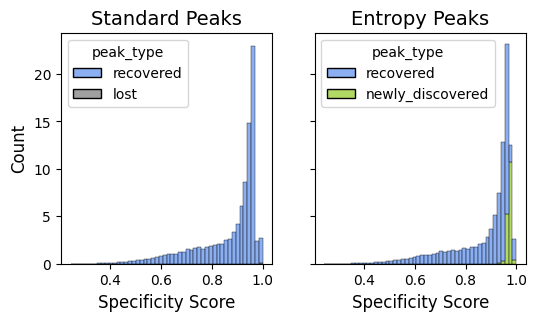

In [ ]:
color_maps = {'recovered': 'cornflowerblue', 'lost': 'grey', 'newly_discovered': 'yellowgreen', 'others': 'red'}

fig, ax = plt.subplots(1, 2, figsize=(6,3), sharex=True, sharey=True)
sns.histplot(data=peak.var, x='specificity_score', hue='peak_type', 
             stat="percent",common_norm=True,  palette=color_maps, 
             multiple='stack', bins=50, ax=ax[0])
ax[0].set_title('Standard Peaks', fontsize=14)
ax[0].set_xlabel('Specificity Score', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)

sns.histplot(data=entropy_peak.var, x='specificity_score', hue='peak_type',
                stat="percent",common_norm=True, palette=color_maps,
                multiple='stack', bins=50, ax=ax[1])
ax[1].set_title('Entropy Peaks', fontsize=14)
ax[1].set_xlabel('Specificity Score', fontsize=12)
ax[1].set_ylabel('Count', fontsize=12)


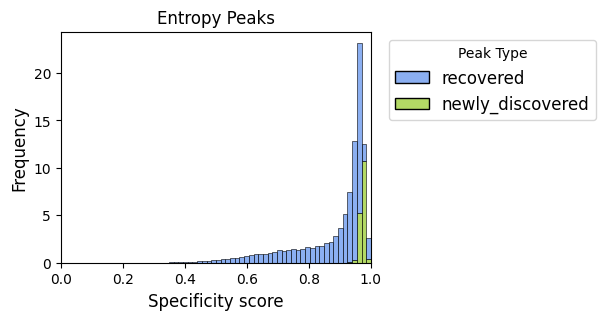

In [ ]:
color_maps = {'recovered': 'cornflowerblue', 'lost': 'grey', 'newly_discovered': 'yellowgreen', 'others': 'red'}

fig, ax = plt.subplots( figsize=(4,3))


sns.histplot(data=entropy_peak.var, x='specificity_score', hue='peak_type',
                stat="percent",common_norm=True, palette=color_maps, hue_order=[  'recovered', 'newly_discovered',],
                multiple='stack', bins=50, ax=ax)
ax.set_title('Entropy Peaks', fontsize=12)
ax.set_xlabel('Specificity score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_xlim(0, 1)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1.03, 1), title='Peak Type', fontsize=12)

Text(0.5, 0.98, 'Standard Peaks')

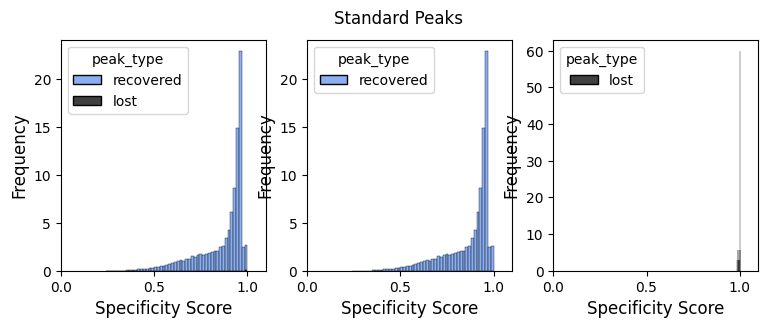

In [ ]:
color_maps = {'recovered': 'cornflowerblue', 'lost': 'black', 'newly_discovered': 'yellowgreen', 'others': 'red'}


fig, ax = plt.subplots(1, 3, figsize=(9,3), sharex=False, sharey=False)
sns.histplot(data=peak.var, x='specificity_score', hue='peak_type',
                stat="percent",common_norm=True, palette=color_maps,
                multiple='stack', bins=50, ax=ax[0])
# ax[0].set_title('Standard Peaks', fontsize=14)
ax[0].set_xlabel('Specificity Score', fontsize=12)
ax[0].set_ylabel('Frequency', fontsize=12)


sns.histplot(data=peak.var.loc[peak.var['peak_type'] == 'recovered'], x='specificity_score',  hue='peak_type',
             stat="percent",common_norm=True,  palette=color_maps,
             multiple='stack', bins=50, ax=ax[1])
# ax[1].set_title('Standard Peaks', fontsize=14)
ax[1].set_xlabel('Specificity Score', fontsize=12)
ax[1].set_ylabel('Frequency', fontsize=12)

sns.histplot(data=peak.var.loc[peak.var['peak_type'] == 'lost'], x='specificity_score', hue='peak_type',
                stat="percent",common_norm=True, palette=color_maps,
                multiple='stack', bins=50, ax=ax[2])
# ax[2].set_title('Standard Peaks', fontsize=14)
ax[2].set_xlabel('Specificity Score', fontsize=12)
ax[2].set_ylabel('Frequency', fontsize=12)


for i in range(3):
    ax[i].set_xlim(0, 1.1)
    #sns.move_legend(ax[i], "upper left", bbox_to_anchor=(3.03 - i, 1), title='Peak Type', fontsize=12)
    
fig.suptitle('Standard Peaks', fontsize=12)

## Check Peak specificity at ATAC cluster level

In [ ]:
####
# For standard peaks
standard_peak_at_cluster_level = pd.DataFrame(index=peak.var['peak'], columns=peak.obs['clusters_peakvi_higherres_standard'].cat.categories)
for c in peak.obs['clusters_peakvi_higherres_standard'].cat.categories:
    a = peak[peak.obs['clusters_peakvi_higherres_standard'] == c, :].X.sum(axis=0 )
    standard_peak_at_cluster_level[c] = np.asarray(a).flatten()


standard_peak_at_cluster_level_h5ad = sc.AnnData(standard_peak_at_cluster_level.T)

standard_peak_at_cluster_level_h5ad.var['recovered'] = standard_peak_at_cluster_level_h5ad.var.index.isin(recovered_peaks_anno['Standard_peak'])
standard_peak_at_cluster_level_h5ad.var['lost'] = standard_peak_at_cluster_level_h5ad.var.index.isin(lost_peaks_anno.index)
standard_peak_at_cluster_level_h5ad.var['peak_type'] = standard_peak_at_cluster_level_h5ad.var.apply(lambda x: 'recovered' if x['recovered'] else ('lost' if x['lost'] else 'others'), axis=1)

####
# For entropy peaks
entropy_peak_at_cluster_level = pd.DataFrame(index=entropy_peak.var['peak'], columns=entropy_peak.obs['clusters_peakvi_higherres_entropy'].cat.categories)
for c in entropy_peak.obs['clusters_peakvi_higherres_entropy'].cat.categories:
    a = entropy_peak[entropy_peak.obs['clusters_peakvi_higherres_entropy'] == c, :].X.sum(axis=0 )
    entropy_peak_at_cluster_level[c] = np.asarray(a).flatten()
    
entropy_peak_at_cluster_level_h5ad = sc.AnnData(entropy_peak_at_cluster_level.T)

entropy_peak_at_cluster_level_h5ad.var['recovered'] = entropy_peak_at_cluster_level_h5ad.var.index.isin(recovered_peaks_anno['Entropy_peak'])
entropy_peak_at_cluster_level_h5ad.var['newly_discovered'] = entropy_peak_at_cluster_level_h5ad.var.index.isin(newly_discovered_peaks_anno.index)
entropy_peak_at_cluster_level_h5ad.var['peak_type'] = entropy_peak_at_cluster_level_h5ad.var.apply(lambda x: 'recovered' if x['recovered'] else ('newly_discovered' if x['newly_discovered'] else 'others'), axis=1)


In [ ]:
entropy_peak_at_cluster_level_h5ad, standard_peak_at_cluster_level_h5ad

(AnnData object with n_obs × n_vars = 12 × 36730
     var: 'recovered', 'newly_discovered', 'peak_type',
 AnnData object with n_obs × n_vars = 12 × 31116
     var: 'recovered', 'lost', 'peak_type')

In [ ]:
standard_peak_at_cluster_level_h5ad.var['presence_in_Ngroups'] = (standard_peak_at_cluster_level_h5ad.X > 0).sum(axis=0)
entropy_peak_at_cluster_level_h5ad.var['presence_in_Ngroups'] = (entropy_peak_at_cluster_level_h5ad.X > 0).sum(axis=0)

# Both standard-peak and entropy-peak have same number of clusters
standard_peak_at_cluster_level_h5ad.var['specificity_score'] = 1 - (standard_peak_at_cluster_level_h5ad.var['presence_in_Ngroups'] / standard_peak_at_cluster_level_h5ad.shape[0])
entropy_peak_at_cluster_level_h5ad.var['specificity_score'] = 1 - (entropy_peak_at_cluster_level_h5ad.var['presence_in_Ngroups'] / entropy_peak_at_cluster_level_h5ad.shape[0])

In [ ]:
standard_peak_at_cluster_level_h5ad.var.head()

,recovered,lost,peak_type,presence_in_Ngroups,specificity_score
peak,,,,,
chr1:817208-817719,True,False,recovered,11,0.083333
chr1:826857-828146,True,False,recovered,12,0.000000
chr1:869760-870205,True,False,recovered,12,0.000000
chr1:904403-905173,True,False,recovered,12,0.000000
chr1:906808-907046,True,False,recovered,7,0.416667


(0.0, 1.1)

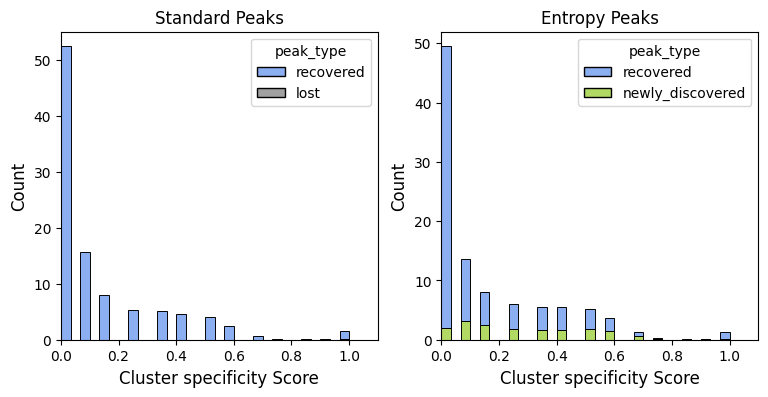

In [ ]:
color_maps = {'recovered': 'cornflowerblue', 'lost': 'grey', 'newly_discovered': 'yellowgreen', 'others': 'red'}
fig, ax = plt.subplots(1, 2, figsize=(9,4))
sns.histplot(data=standard_peak_at_cluster_level_h5ad.var, x='specificity_score', hue='peak_type', 
             stat="percent",common_norm=True,  palette=color_maps,
             multiple='stack', bins=30, ax=ax[0])
ax[0].set_title('Standard Peaks', fontsize=12)
ax[0].set_xlabel('Cluster specificity Score', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)
ax[0].set_xlim(0, 1.1)

sns.histplot(data=entropy_peak_at_cluster_level_h5ad.var, x='specificity_score', hue='peak_type',
                stat="percent",common_norm=True, palette=color_maps,
                multiple='stack', bins=30, ax=ax[1])
ax[1].set_title('Entropy Peaks', fontsize=12)
ax[1].set_xlabel('Cluster specificity Score', fontsize=12)
ax[1].set_ylabel('Count', fontsize=12)
ax[1].set_xlim(0, 1.1)

### Count them up

In [ ]:
standard_peak_specificity = standard_peak_at_cluster_level_h5ad.var.groupby(['presence_in_Ngroups', 'peak_type']).size().unstack(fill_value=0)

entropy_peak_specificity = entropy_peak_at_cluster_level_h5ad.var.groupby(['presence_in_Ngroups', 'peak_type']).size().unstack(fill_value=0)

standard_peak_specificity['total_peaks'] = standard_peak_specificity.sum(axis=1)
entropy_peak_specificity['total_peaks'] = entropy_peak_specificity.sum(axis=1)

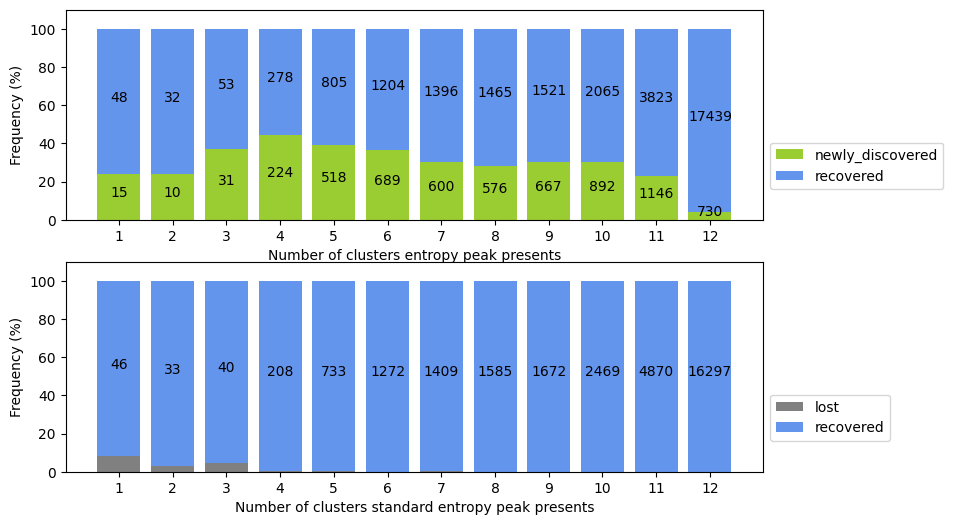

In [ ]:
color_map = {'total_DARs': 'peru', 'recovered': 'cornflowerblue', 'lost': 'grey', 'newly_discovered': 'yellowgreen'}


width = 0.8  # the width of the bars
fig, ax = plt.subplots( 2, 1, figsize=(9,6))


x = np.arange(entropy_peak_specificity.shape[0])  # the label locations
bottom = np.zeros(entropy_peak_specificity.shape[0])
for attribute  in [ 'newly_discovered', 'recovered']:
    
    y_perc = entropy_peak_specificity[attribute] / entropy_peak_specificity['total_peaks'] * 100
    rects = ax[0].bar(x[1:] , y_perc[1:],  width, label=attribute, color=color_map[attribute], bottom=bottom[1:])
    bottom += y_perc
            
    value_labels = entropy_peak_specificity[attribute]
    value_pos = 'center'
    ax[0].bar_label(rects, labels=value_labels[1:] , padding=3, fontsize=10, label_type=value_pos) 


# Add some text for labels, title and custom x-axis tick labels, etc.
ax[0].set_ylabel('Frequency (%)')

ax[0].set_xlabel('Number of clusters entropy peak presents', fontsize=10) 
ax[0].set_xticks(x[1:] , standard_peak_specificity.index[1:])
ax[0].legend(loc='upper left',ncols=1, bbox_to_anchor=(1,0.4), fontsize=10)
ax[0].set_ylim(0, 100 * 1.1)
y_labels = ax[0].get_yticklabels()
y_labels[-1].set_visible(False)

x = np.arange(standard_peak_specificity.shape[0])  # the label locations
bottom = np.zeros(standard_peak_specificity.shape[0])

for attribute  in [ 'lost', 'recovered']:
    
    y_perc = standard_peak_specificity[attribute] / standard_peak_specificity['total_peaks'] * 100
    rects = ax[1].bar(x[1:] , y_perc[1:],  width, label=attribute, color=color_map[attribute], bottom=bottom[1:])
    bottom += y_perc

    value_labels = standard_peak_specificity[attribute]
    value_pos = 'center'

ax[1].bar_label(rects, labels=value_labels[1:] , padding=3, fontsize=10, label_type=value_pos) 
# Add some text for labels, title and custom x-axis tick labels, etc.
ax[1].set_ylabel('Frequency (%)')
ax[1].set_xlabel('Number of clusters standard entropy peak presents', fontsize=10) 
ax[1].set_xticks(x[1:], entropy_peak_specificity.index[1:])
ax[1].legend(loc='upper left', ncols=1, bbox_to_anchor=(1,0.4), fontsize=10)
ax[1].set_ylim(0, 100* 1.1)
y_labels = ax[1].get_yticklabels()
y_labels[-1].set_visible(False)


In [ ]:
entropy_peak_specificity

peak_type,newly_discovered,recovered,total_peaks
presence_in_Ngroups,,,
0,43,460,503
1,15,48,63
2,10,32,42
3,31,53,84
4,224,278,502
5,518,805,1323
6,689,1204,1893
7,600,1396,1996
8,576,1465,2041


### Alluvial plot

In [ ]:
import pyalluvial.alluvial as alluvial

In [ ]:
standard_peak_celltype_specific_peaks = standard_peak_at_cluster_level_h5ad.var[standard_peak_at_cluster_level_h5ad.var['presence_in_Ngroups'] == 1].copy()
standard_peak_celltype_specific_peaks['peak_name'] = standard_peak_celltype_specific_peaks.index.values


for peak_name in standard_peak_celltype_specific_peaks.index:
    
    standard_peak_cluster_index = standard_peak_at_cluster_level_h5ad.X[:, standard_peak_at_cluster_level_h5ad.var.index == peak_name].flatten().nonzero()[0][0]
    freq = standard_peak_at_cluster_level_h5ad.X[:, standard_peak_at_cluster_level_h5ad.var.index == peak_name].flatten()[standard_peak_cluster_index]
    standard_peak_cluster = standard_peak_at_cluster_level_h5ad.obs.index[standard_peak_cluster_index]
    standard_peak_celltype_specific_peaks.loc[peak_name, 'presence_in_standard_peak_cluster'] = standard_peak_cluster
    standard_peak_celltype_specific_peaks.loc[peak_name, 'freq'] = freq
    


entropy_peak_celltype_specific_peaks = entropy_peak_at_cluster_level_h5ad.var[entropy_peak_at_cluster_level_h5ad.var['presence_in_Ngroups'] == 1].copy()
entropy_peak_celltype_specific_peaks['peak_name'] = entropy_peak_celltype_specific_peaks.index.values

for peak_name in entropy_peak_celltype_specific_peaks.index:
    
    entropy_peak_cluster_index = entropy_peak_at_cluster_level_h5ad.X[:, entropy_peak_at_cluster_level_h5ad.var.index == peak_name].flatten().nonzero()[0][0]
    freq = entropy_peak_at_cluster_level_h5ad.X[:, entropy_peak_at_cluster_level_h5ad.var.index == peak_name].flatten()[entropy_peak_cluster_index]
    entropy_peak_cluster = entropy_peak_at_cluster_level_h5ad.obs.index[entropy_peak_cluster_index]
    entropy_peak_celltype_specific_peaks.loc[peak_name, 'presence_in_entropy_peak_cluster'] = entropy_peak_cluster
    entropy_peak_celltype_specific_peaks.loc[peak_name, 'freq'] = freq

In [ ]:
standard_peak_celltype_specific_peaks.head()

,recovered,lost,peak_type,presence_in_Ngroups,peak_name,presence_in_standard_peak_cluster,freq
peak,,,,,,,
chr1:2660670-2663058,True,False,recovered,1,chr1:2660670-2663058,11,1.0
chr1:2748299-2748725,False,True,lost,1,chr1:2748299-2748725,11,1.0
chr1:16585467-16585936,True,False,recovered,1,chr1:16585467-16585936,11,3.0
chr1:16700548-16701704,True,False,recovered,1,chr1:16700548-16701704,0,1.0
chr1:16757172-16758200,True,False,recovered,1,chr1:16757172-16758200,11,1.0


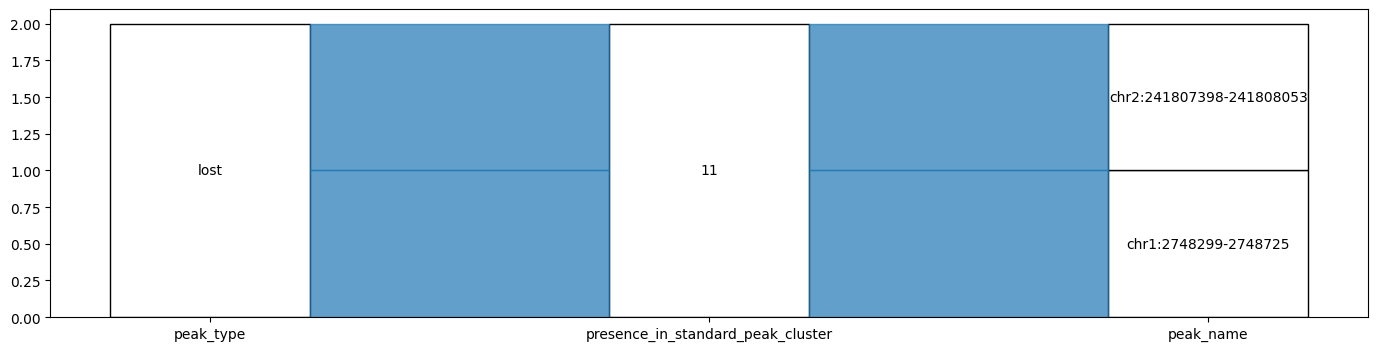

In [ ]:
fig = alluvial.plot(
   df=standard_peak_celltype_specific_peaks.loc[standard_peak_celltype_specific_peaks['lost']], 
   xaxis_names=['peak_type', 'presence_in_standard_peak_cluster', 'peak_name'], 
   y_name='freq', 
   alluvium='presence_in_standard_peak_cluster',
   # order_dict={'peak_type': ['lost', 'recovered']}, 
   figsize = (17, 4) 
)

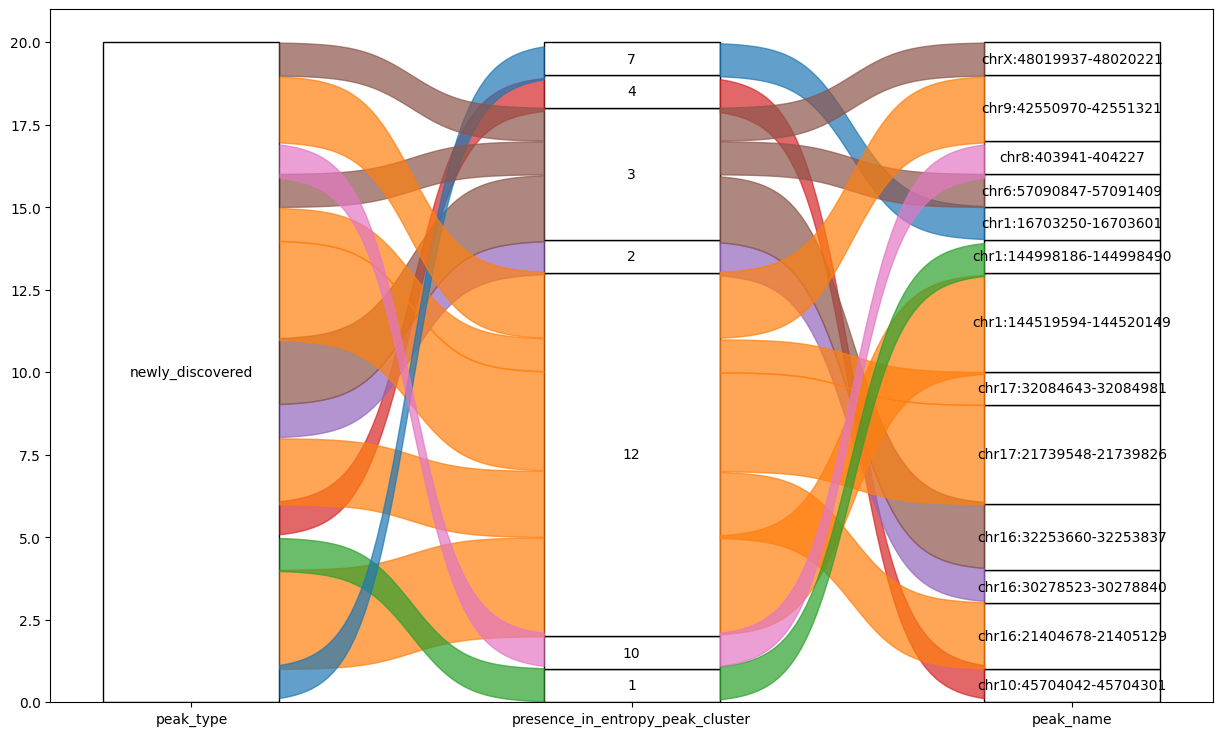

In [ ]:
fig = alluvial.plot(
   df=entropy_peak_celltype_specific_peaks.loc[entropy_peak_celltype_specific_peaks['newly_discovered']], 
   xaxis_names=['peak_type', 'presence_in_entropy_peak_cluster', 'peak_name'], 
   y_name='freq', 
   alluvium='presence_in_entropy_peak_cluster',
   # order_dict={'peak_type': ['newly_discovered', 'recovered']}, 
   figsize = (15, 9) 
   
)

# Peak  DARs 

## First take a look at ATAC space 

In [39]:
if 'leiden_RNA_scVI' in entropy_peak.obs.columns:
    entropy_peak.obs.drop('leiden_RNA_scVI', axis=1, inplace=True)    
entropy_peak.obs = entropy_peak.obs.merge(h5_rna.obs[['leiden_RNA_scVI', 'atac_bc']], left_index=True, right_on='atac_bc', how='left')
    
if 'leiden_RNA_scVI'  in peak.obs.columns:
    peak.obs.drop('leiden_RNA_scVI', axis=1, inplace=True)
peak.obs = peak.obs.merge(h5_rna.obs[['leiden_RNA_scVI', 'atac_bc']], left_index=True, right_on='atac_bc', how='left')
    

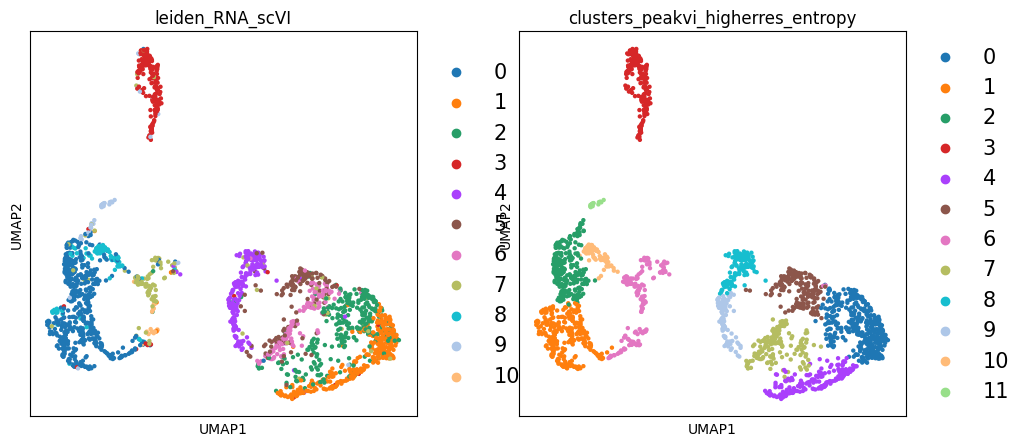

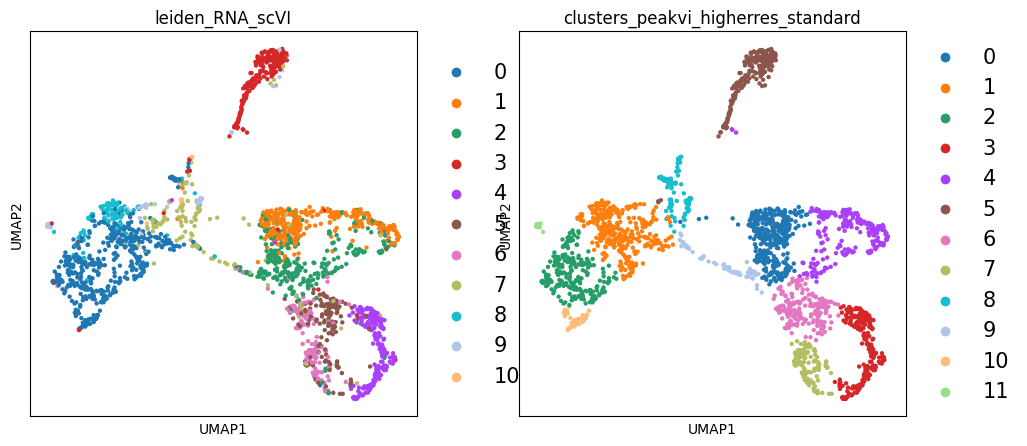

In [40]:
with plt.rc_context({'figure.figsize': (5, 5)}):
    sc.pl.umap(entropy_peak, color=['leiden_RNA_scVI', 'clusters_peakvi_higherres_entropy'], wspace=0.15, ncols=2, size=40, legend_fontsize=15, show=False)
    sc.pl.umap(peak, color=['leiden_RNA_scVI', 'clusters_peakvi_higherres_standard'], wspace=0.15, ncols=2, size=40, legend_fontsize=15, show=False)

## GET DARs

In [ ]:
standard_DARs = {}
for cluster in peak.obs['clusters_peakvi_higherres_standard'].unique():
    print(f" DARs on StandardPeak-higherres-cluster {cluster}")
    standard_DARs[cluster] = standard_peak_model.differential_accessibility(
        groupby="clusters_peakvi_higherres_standard", group1=cluster,  two_sided=True
    )

 DARs on StandardPeak-higherres-cluster 6
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.66s/it]
 DARs on StandardPeak-higherres-cluster 5
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.18s/it]
 DARs on StandardPeak-higherres-cluster 1
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.14s/it]
 DARs on StandardPeak-higherres-cluster 8
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.21s/it]
 DARs on StandardPeak-higherres-cluster 0
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.18s/it]
 DARs on StandardPeak-higherres-cluster 3
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.18s/it]
 DARs on StandardPeak-higherres-cluster 2
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.19s/it]
 DARs on StandardPeak-higherres-cluster 9
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.18s/it]
 DARs on StandardPeak-higherres-cluster 7
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.18s/it]
 DARs on StandardPeak-higherres-cluster 4
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.22s/it]
 DARs on StandardPeak-higherres-cluster 10
DE...: 

In [ ]:
peak.var.head()

,peak,recovered,lost,peak_type,presence_in_Ncells,specificity_score
0,chr1:817208-817719,True,False,recovered,91,0.957197
1,chr1:826857-828146,True,False,recovered,355,0.833020
2,chr1:869760-870205,True,False,recovered,235,0.889464
3,chr1:904403-905173,True,False,recovered,210,0.901223
4,chr1:906808-907046,True,False,recovered,55,0.974130


In [ ]:
relate_labels2 = h5_rna.obs.groupby(['clusters_peakvi_higherres_standard', 'clusters_peakvi_higherres_entropy']).size().unstack(fill_value=0)
ordered_col, remained_col = order_m(relate_labels2.values)

# # Now map the best matching clusters
entropy_peak.obs['reorder_clusters_peakvi_higherres_entropy'] = entropy_peak.obs['clusters_peakvi_higherres_entropy'].cat.reorder_categories([str(i) for i in ordered_col+remained_col], ordered=False)

/tmp/ipykernel_577536/442458105.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  relate_labels2 = h5_rna.obs.groupby(['clusters_peakvi_higherres_standard', 'clusters_peakvi_higherres_entropy']).size().unstack(fill_value=0)


In [ ]:
entropy_DARs = {}
for cluster in entropy_peak.obs['reorder_clusters_peakvi_higherres_entropy'].unique():
    print(f" DARs on EntropyPeak-highres-cluster {cluster}")
    entropy_DARs[cluster] = entropy_peak_model.differential_accessibility(
        groupby="reorder_clusters_peakvi_higherres_entropy", group1=cluster,  two_sided=True
    )

 DARs on EntropyPeak-highres-cluster 5
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.91s/it]
 DARs on EntropyPeak-highres-cluster 3
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.76s/it]
 DARs on EntropyPeak-highres-cluster 2
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.84s/it]
 DARs on EntropyPeak-highres-cluster 0
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.79s/it]
 DARs on EntropyPeak-highres-cluster 6
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.78s/it]
 DARs on EntropyPeak-highres-cluster 8
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.82s/it]
 DARs on EntropyPeak-highres-cluster 1
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.87s/it]
 DARs on EntropyPeak-highres-cluster 10
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.89s/it]
 DARs on EntropyPeak-highres-cluster 7
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.80s/it]
 DARs on EntropyPeak-highres-cluster 4
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.85s/it]
 DARs on EntropyPeak-highres-cluster 9
DE...: 100%|██████████| 1/1 [00:04<00:00

In [ ]:
## manually change effect-size sign 

for cluster in entropy_DARs.keys():
    entropy_DARs[cluster]['effect_size_correct_sign'] = -entropy_DARs[cluster]['effect_size']
    
for cluster in standard_DARs.keys():
    standard_DARs[cluster]['effect_size_correct_sign'] = -standard_DARs[cluster]['effect_size']

## Label peak types for DARs

### Prepare for vis

In [ ]:

for key in entropy_DARs.keys():

    id = entropy_DARs[key].index.values 
    entropy_DARs[key]['Entropy_peak'] = entropy_peak.var.loc[id, 'peak']
    entropy_DARs[key]['lost_peak'] = entropy_DARs[key]['Entropy_peak'].isin(lost_peaks_anno.index)
    entropy_DARs[key]['newly_discovered_peak'] = entropy_DARs[key]['Entropy_peak'].isin(newly_discovered_peaks_anno.index)
    entropy_DARs[key]['recovered_peak'] = entropy_DARs[key]['Entropy_peak'].isin(recovered_peaks_anno["Entropy_peak"])


for key in standard_DARs.keys():
    
    id = standard_DARs[key].index.values
    standard_DARs[key]['Standard_peak'] = peak.var.loc[id, 'peak']
    standard_DARs[key]['lost_peak'] = standard_DARs[key]['Standard_peak'].isin(lost_peaks_anno.index)
    standard_DARs[key]['newly_discovered_peak'] = standard_DARs[key]['Standard_peak'].isin(newly_discovered_peaks_anno.index)
    standard_DARs[key]['recovered_peak'] = standard_DARs[key]['Standard_peak'].isin(recovered_peaks_anno["Standard_peak"])

/tmp/ipykernel_577536/1146403970.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  standard_DARs[key]['Standard_peak'] = peak.var.loc[id, 'peak']
/tmp/ipykernel_577536/1146403970.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  standard_DARs[key]['lost_peak'] = standard_DARs[key]['Standard_peak'].isin(lost_peaks_anno.index)
/tmp/ipykernel_577536/1146403970.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value

### Vis on DARs

In [ ]:
h5_rna.obs['clusters_peakvi_higherres_standard'].cat.categories , h5_rna.obs['reorder_clusters_peakvi_higherres_entropy'].cat.categories

(Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11'], dtype='object'),
 Index(['0', '2', '1', '8', '4', '3', '5', '7', '6', '9', '10', '11'], dtype='object'))

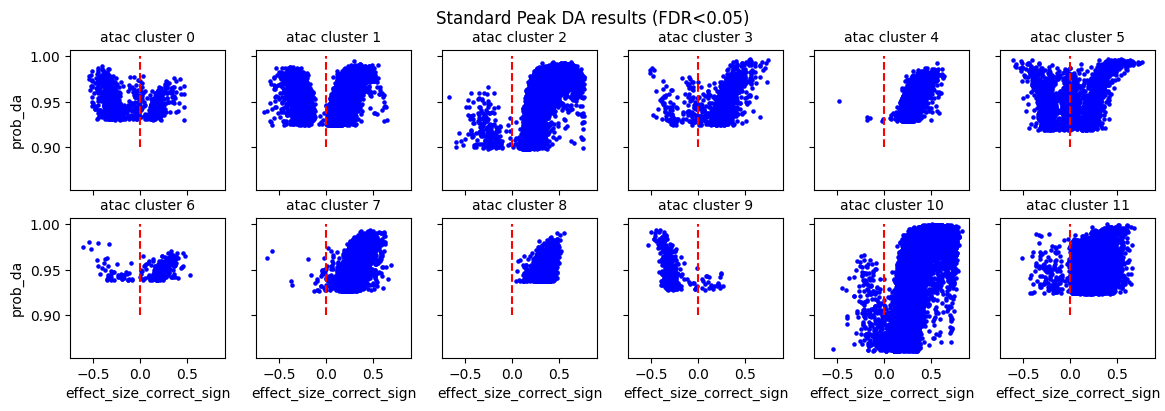

In [ ]:

fig, axes = plt.subplots(2, 6,  figsize=(14,4),  sharex=True, sharey=True)
axes = axes.flatten()
# for i, cluster in enumerate(standard_DARs.keys()):
# To plot in corresponding cluster order
for i, cluster in enumerate(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']):
    ax = axes[i]
    standard_DARs[cluster].loc[(standard_DARs[cluster]['is_da_fdr']) & (standard_DARs[cluster]['recovered_peak'])].plot.scatter(x='effect_size_correct_sign', y='prob_da', ax=ax, title=f'Standard-Peak cluster {cluster}', s = 5, c='blue' ) 
    standard_DARs[cluster].loc[(standard_DARs[cluster]['is_da_fdr']) & (standard_DARs[cluster]['lost_peak'])].plot.scatter(x='effect_size_correct_sign', y='prob_da', ax=ax, title=f'Standard-Peak cluster {cluster}', s = 5, c='grey' )   
    ax.vlines(x=0, color='red', ymin=0.9, ymax=1, linestyle='--')
    ax.set_title(f'atac cluster {cluster}', fontsize=10)

plt.suptitle('Standard Peak DA results (FDR<0.05) ', fontsize=12)
plt.show()

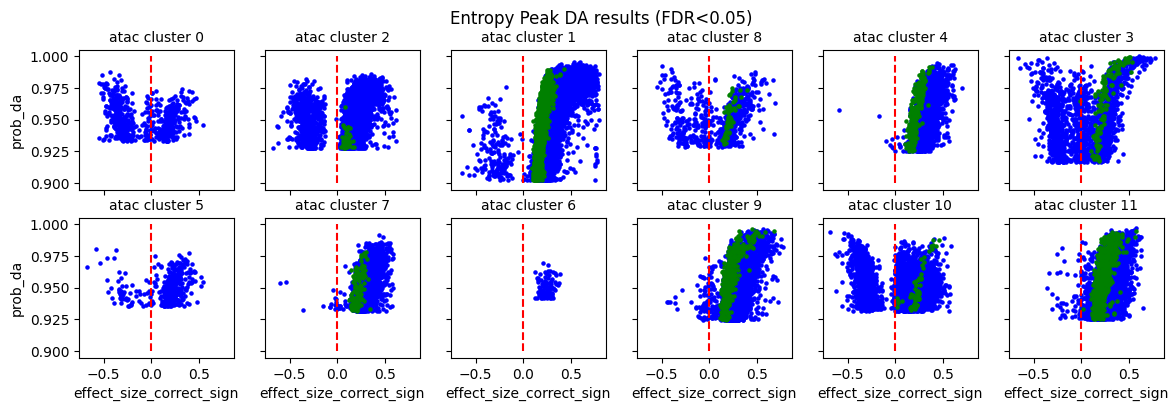

In [ ]:
fig, axes = plt.subplots(2, 6, figsize=(14,4), sharex=True, sharey=True)
axes = axes.flatten()
# for i, cluster in enumerate(entropy_DARs.keys()):
# To plot in corresponding cluster order
for i, cluster in enumerate(['0', '2', '1', '8', '4', '3', '5', '7', '6', '9', '10', '11']):
    ax = axes[i]
    entropy_DARs[cluster].loc[(entropy_DARs[cluster]['is_da_fdr']) & (entropy_DARs[cluster]['recovered_peak'])].plot.scatter(x='effect_size_correct_sign', y='prob_da', \
        ax=ax, title=f'Entropy-Peak cluster {cluster}', s=5, c='blue' )     
    entropy_DARs[cluster].loc[(entropy_DARs[cluster]['is_da_fdr']) & (entropy_DARs[cluster]['newly_discovered_peak'])].plot.scatter(x='effect_size_correct_sign', y='prob_da', \
        ax=ax, title=f'Entropy-Peak cluster {cluster}', s=5 , c='green') 
    ax.vlines(x=0, color='red', ymin=0.9, ymax=1, linestyle='--')
    ax.set_title(f'atac cluster {cluster}', fontsize=10)

plt.suptitle('Entropy Peak DA results (FDR<0.05) ', fontsize=12)
plt.show()

### Save

In [ ]:
# Save some efforts in visualization
entropy_DARs_columns = entropy_DARs['0'].columns.to_list()
standard_DARs_columns = standard_DARs['0'].columns.to_list()
if 'chrom' not in entropy_DARs_columns:
    for cluster in entropy_DARs.keys():
        entropy_DARs[cluster]['chrom'] = entropy_DARs[cluster]['Entropy_peak'].apply(lambda x: x.split(':')[0])
        entropy_DARs[cluster]['start'] = entropy_DARs[cluster]['Entropy_peak'].apply(lambda x: int(x.split(':')[1].split('-')[0]))  
        entropy_DARs[cluster]['end'] = entropy_DARs[cluster]['Entropy_peak'].apply(lambda x: int(x.split('-')[1]))
        entropy_DARs[cluster] = entropy_DARs[cluster][['chrom', 'start', 'end'] + entropy_DARs_columns] # Reorder use for bed file 

if 'chrom' not in standard_DARs:
    for cluster in standard_DARs.keys():
        standard_DARs[cluster]['chrom'] = standard_DARs[cluster]['Standard_peak'].apply(lambda x: x.split(':')[0])
        standard_DARs[cluster]['start'] = standard_DARs[cluster]['Standard_peak'].apply(lambda x: int(x.split(':')[1].split('-')[0]))  
        standard_DARs[cluster]['end'] = standard_DARs[cluster]['Standard_peak'].apply(lambda x: int(x.split('-')[1]))
        standard_DARs[cluster] = standard_DARs[cluster][['chrom', 'start', 'end'] + standard_DARs_columns]


# Save DARs results
atac_cluster_DARs_dir = os.path.join(entropy_dir, '_atac_cluster_DARs')
standard_DARs_dir = os.path.join(atac_cluster_DARs_dir, '_standard_peak_cluster_DARs')
os.makedirs(standard_DARs_dir, exist_ok=True)

for cluster in standard_DARs.keys():
    all_dars_file = os.path.join(standard_DARs_dir, f'standard_peak_cluster_{cluster}_DARs.csv')
    standard_DARs[cluster].to_csv(all_dars_file, index=False, sep='\t')
    
    recovered_dars_file = os.path.join(standard_DARs_dir, f'standard_peak_cluster_{cluster}_DARs_in_recovered_peaks.csv')
    standard_DARs[cluster].loc[standard_DARs[cluster]['recovered_peak']].to_csv(recovered_dars_file, index=False, sep='\t')
    
    lost_dars_file = os.path.join(standard_DARs_dir, f'standard_peak_cluster_{cluster}_DARs_in_lost_peaks.csv')
    standard_DARs[cluster].loc[standard_DARs[cluster]['lost_peak']].to_csv(lost_dars_file, index=False, sep='\t')
    
    
entropy_DARs_dir = os.path.join(atac_cluster_DARs_dir, '_entropy_peak_cluster_DARs')
os.makedirs(entropy_DARs_dir, exist_ok=True)

for cluster in entropy_DARs.keys():
    all_dars_file = os.path.join(entropy_DARs_dir, f'entropy_peak_cluster_{cluster}_DARs.csv')
    entropy_DARs[cluster].to_csv(all_dars_file, index=False, sep='\t')
    
    recovered_dars_file = os.path.join(entropy_DARs_dir, f'entropy_peak_cluster_{cluster}_DARs_in_recovered_peaks.csv')
    entropy_DARs[cluster].loc[entropy_DARs[cluster]['recovered_peak']].to_csv(recovered_dars_file, index=False, sep='\t')
    
    newly_discovered_dars_file = os.path.join(entropy_DARs_dir, f'entropy_peak_cluster_{cluster}_DARs_in_newly_discovered_peaks.csv')
    entropy_DARs[cluster].loc[entropy_DARs[cluster]['newly_discovered_peak']].to_csv(newly_discovered_dars_file, index=False, sep='\t')
    

significant_standard_DARs_dir = os.path.join(atac_cluster_DARs_dir, 'significant_standard_peak_cluster_DARs')
os.makedirs(significant_standard_DARs_dir, exist_ok=True)
for cluster in standard_DARs.keys():
    all_dars_file = os.path.join(significant_standard_DARs_dir, f'cluster_{cluster}_DARs.csv')
    standard_DARs[cluster].loc[standard_DARs[cluster]['is_da_fdr']].to_csv(all_dars_file, index=False, sep='\t')
    
    recovered_dars_file = os.path.join(significant_standard_DARs_dir, f'cluster_{cluster}_DARs_in_recovered_peaks.csv')
    standard_DARs[cluster].loc[(standard_DARs[cluster]['is_da_fdr']) & (standard_DARs[cluster]['recovered_peak'])].to_csv(recovered_dars_file, index=False, sep='\t')
    
    lost_dars_file = os.path.join(significant_standard_DARs_dir, f'cluster_{cluster}_DARs_in_lost_peaks.csv')
    standard_DARs[cluster].loc[(standard_DARs[cluster]['is_da_fdr']) & (standard_DARs[cluster]['lost_peak'] )].to_csv(lost_dars_file, index=False, sep='\t')
    
    
significant_entropy_DARs_dir = os.path.join(atac_cluster_DARs_dir, 'significant_entropy_peak_cluster_DARs')
os.makedirs(significant_entropy_DARs_dir, exist_ok=True)
for cluster in entropy_DARs.keys():
    all_dars_file = os.path.join(significant_entropy_DARs_dir, f'cluster_{cluster}_DARs.csv')
    entropy_DARs[cluster].loc[entropy_DARs[cluster]['is_da_fdr']].to_csv(all_dars_file, index=False, sep='\t')
    
    recovered_dars_file = os.path.join(significant_entropy_DARs_dir, f'cluster_{cluster}_DARs_in_recovered_peaks.csv')
    entropy_DARs[cluster].loc[(entropy_DARs[cluster]['is_da_fdr']) & (entropy_DARs[cluster]['recovered_peak'])].to_csv(recovered_dars_file, index=False, sep='\t')
    
    newly_discovered_dars_file = os.path.join(significant_entropy_DARs_dir, f'cluster_{cluster}_DARs_in_newly_discovered_peaks.csv')
    entropy_DARs[cluster].loc[(entropy_DARs[cluster]['is_da_fdr']) &(entropy_DARs[cluster]['newly_discovered_peak'])].to_csv(newly_discovered_dars_file, index=False, sep='\t')



/tmp/ipykernel_577536/3448571850.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  standard_DARs[cluster]['chrom'] = standard_DARs[cluster]['Standard_peak'].apply(lambda x: x.split(':')[0])
/tmp/ipykernel_577536/3448571850.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  standard_DARs[cluster]['start'] = standard_DARs[cluster]['Standard_peak'].apply(lambda x: int(x.split(':')[1].split('-')[0]))
/tmp/ipykernel_577536/3448571850.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

In [ ]:
# Can load directory from files now 
# # TODO: finish this chunk and replace doing it all over again to save time for figure updates 
# atac_cluster_DARs_dir = os.path.join(entropy_dir, '_atac_cluster_DARs')
# standard_DARs_dir = os.path.join(atac_cluster_DARs_dir, 'standard_peak_cluster_DARs')
# entropy_DARs_dir = os.path.join(atac_cluster_DARs_dir, 'entropy_peak_cluster_DARs')


# entropy_DARs = {}
# for cluster in 


### STATS on DARs

In [ ]:
def create_DARs_stats(DARs_stats_dict, index_name):
    DAR_stats_df = pd.DataFrame(columns=['total_DARs', 'DARs_in_recovered_peaks', 'DARs_in_lost_peaks', 'DARs_in_newly_discovered_peaks'])
    
    for key in DARs_stats_dict.keys():
        NDAR_in_recovered = DARs_stats_dict[key].loc[DARs_stats_dict[key]['is_da_fdr'], 'recovered_peak'].sum()
        NDAR_in_lost = DARs_stats_dict[key].loc[DARs_stats_dict[key]['is_da_fdr'], 'lost_peak'].sum()
        NDAR_in_newly_discovered = DARs_stats_dict[key].loc[DARs_stats_dict[key]['is_da_fdr'], 'newly_discovered_peak'].sum()
        
        DAR_stats_df.loc[key, 'total_DARs'] = DARs_stats_dict[key]['is_da_fdr'].sum()
        DAR_stats_df.loc[key, 'DARs_in_recovered_peaks'] = NDAR_in_recovered
        DAR_stats_df.loc[key, 'DARs_in_lost_peaks'] = NDAR_in_lost
        DAR_stats_df.loc[key, 'DARs_in_newly_discovered_peaks'] = NDAR_in_newly_discovered
        
    DAR_stats_df.index.name = index_name
    
    return DAR_stats_df

In [ ]:
entropy_DARs_stats = create_DARs_stats(entropy_DARs, index_name='Entropy_peak_cluster')
standard_DARs_stats = create_DARs_stats(standard_DARs, index_name='Standard_peak_cluster')


standard_DARs_stats_perc = standard_DARs_stats.div(standard_DARs_stats['total_DARs'], axis=0) * 100
standard_DARs_stats_perc.columns = [col + '_perc' for col in standard_DARs_stats_perc.columns]
standard_DARs_stats_perc['total_DARs'] = standard_DARs_stats['total_DARs'] # add back total_DARs column for reference


entropy_DARs_stats_perc = entropy_DARs_stats.div(entropy_DARs_stats['total_DARs'], axis=0) * 100
entropy_DARs_stats_perc.columns = [col + '_perc' for col in entropy_DARs_stats_perc.columns]
entropy_DARs_stats_perc['total_DARs'] = entropy_DARs_stats['total_DARs'] # add back total_DARs column for reference

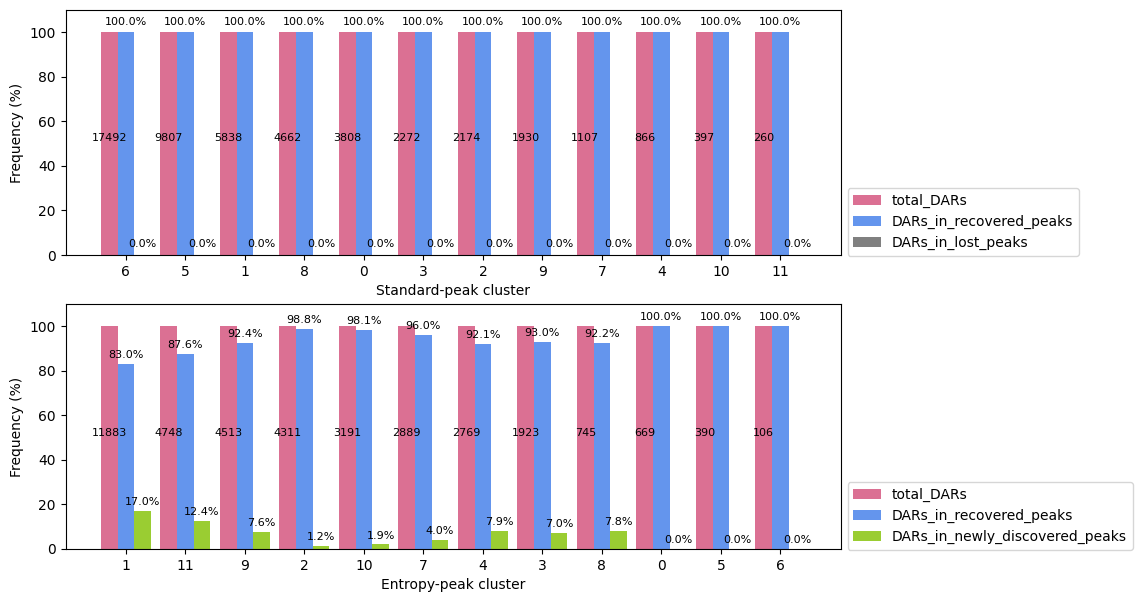

In [ ]:
color_map = {'total_DARs': 'palevioletred', 'DARs_in_recovered_peaks': 'cornflowerblue', 'DARs_in_lost_peaks': 'grey', 'DARs_in_newly_discovered_peaks': 'yellowgreen'}


plot_order_by_total_DARs = standard_DARs_stats.sort_values(by='total_DARs', ascending=False).index.values 
standard_DARs_stats2 = standard_DARs_stats.loc[plot_order_by_total_DARs]
standard_DARs_stats_perc2 = standard_DARs_stats_perc.loc[plot_order_by_total_DARs]

plot_order_by_total_DARs = entropy_DARs_stats.sort_values(by='total_DARs', ascending=False).index.values
entropy_DARs_stats2 = entropy_DARs_stats.loc[plot_order_by_total_DARs]
entropy_DARs_stats_perc2 = entropy_DARs_stats_perc.loc[plot_order_by_total_DARs]



width = 0.28  # the width of the bars
fig, ax = plt.subplots(2, 1, figsize=(10,7))

x = np.arange(standard_DARs_stats2.shape[0])  # the label locations
multiplier = 0
for attribute  in ['total_DARs', 'DARs_in_recovered_peaks', 'DARs_in_lost_peaks']:
    offset = width * multiplier
    rects = ax[0].bar(x + offset, standard_DARs_stats_perc2[attribute+'_perc'], width, label=attribute, color=color_map[attribute])
    if attribute == 'total_DARs':
        value_labels = standard_DARs_stats2[attribute].values
        value_pos = 'center'
        ax[0].bar_label(rects, labels=value_labels , padding=4, fontsize=8, label_type=value_pos) 

    else:
        value_labels = standard_DARs_stats_perc2[attribute+'_perc']
        value_pos = 'edge'
        ax[0].bar_label(rects, labels=[f'{x:,.1f}%' for x in value_labels] , padding=4, fontsize=8, label_type=value_pos) 

    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax[0].set_ylabel('Frequency (%)')
# ax[0].set_title('Standard-Peak cluster DARs statistics')
ax[0].set_xlabel('Standard-peak cluster')
ax[0].set_xticks(x + width, standard_DARs_stats.index)
ax[0].legend(loc='upper left', ncols=1, bbox_to_anchor=(1,0.3), fontsize=10)
ax[0].set_ylim(0, 100 * 1.1)
y_labels = ax[0].get_yticklabels()
y_labels[-1].set_visible(False)



# for attribute  in entropy_DARs_stats.columns:
x = np.arange(entropy_DARs_stats2.shape[0])  # the label locations
multiplier = 0
for attribute  in ['total_DARs', 'DARs_in_recovered_peaks', 'DARs_in_newly_discovered_peaks']:
    offset = width * multiplier
    rects = ax[1].bar(x + offset, entropy_DARs_stats_perc2[attribute+'_perc'], width, label=attribute, color=color_map[attribute])
    if attribute == 'total_DARs':
        value_labels = entropy_DARs_stats2[attribute].values
        value_pos = 'center'
        ax[1].bar_label(rects, labels=value_labels , padding=3, fontsize=8, label_type=value_pos) 

    else:
        value_labels = entropy_DARs_stats_perc2[attribute+'_perc']
        value_pos = 'edge'
        ax[1].bar_label(rects, labels=[f'{x:,.1f}%' for x in value_labels] , padding=3, fontsize=8, label_type=value_pos) 

    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax[1].set_ylabel('Frequency (%)')
# ax[1].set_title('Entropy-Peak cluster DARs statistics')    
ax[1].set_xlabel('Entropy-peak cluster') 
ax[1].set_xticks(x + width, entropy_DARs_stats2.index)
ax[1].legend(loc='upper left', ncols=1, bbox_to_anchor=(1,0.3), fontsize=10)
ax[1].set_ylim(0, 100* 1.1)
y_labels = ax[1].get_yticklabels()
y_labels[-1].set_visible(False)

plt.show()



### Save DARs results

# Check chronical marker gene's chromatin accessible region in peaks 

Ref: Mapping genetic effects on cell type-specific chromatin accessibility and annotating complex immune trait variants using single nucleus ATAC-seq in peripheral blood : Paola Benaglio et al. 

In [ ]:
entropy_peakset_dir = os.path.join(entropy_dir, 'peaks_entropy_filtered')

entropy_peakset_file = os.path.join(entropy_peakset_dir, 'peaks.bed')


entropy_peaksset = pd.read_csv(entropy_peakset_file, header=None, sep='\t')

entropy_peaksset['peak'] = entropy_peaksset[0].astype(str) + ':' + entropy_peaksset[1].astype(str) + '-' + entropy_peaksset[2].astype(str)

In [ ]:
if 'entropy_peak_name' in entropy_peak.var.columns:
    entropy_peak.var.drop('entropy_peak_name', axis=1, inplace=True)

entropy_peak.var = entropy_peak.var.merge(entropy_peaksset[[3, 'peak']], left_on='peak', right_on='peak', how='left')
entropy_peak.var.rename(columns={3: 'entropy_peak_name'}, inplace=True)

entropy_peak.var.head()


,peak,recovered,newly_discovered,peak_type,presence_in_Ncells,specificity_score,entropy_peak_name
0,chr1:817095-817735,True,False,recovered,93,0.956256,peak_29
1,chr1:826855-828152,True,False,recovered,355,0.833020,peak_30
2,chr1:869759-870207,True,False,recovered,235,0.889464,peak_31
3,chr1:904394-905173,True,False,recovered,210,0.901223,peak_32
4,chr1:906808-907056,True,False,recovered,56,0.973659,peak_33


In [ ]:

entropy_peak_plot = entropy_peak.copy()
entropy_peak_plot.var.set_index('entropy_peak_name', inplace=True)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


KeyError: 'Could not find key leiden_RNA_scVI in .var_names or .obs.columns.'

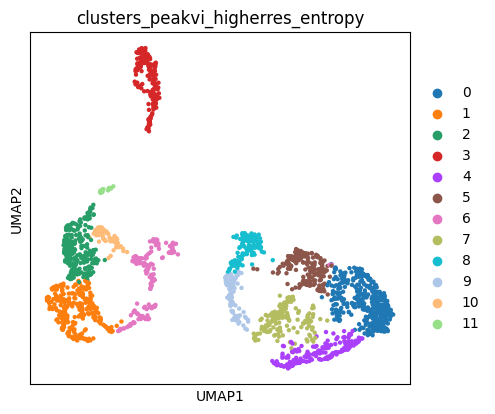

In [ ]:
# NK-cells  
## NCR1  
# name: peak_19704
# location: chr19:54905933-54906212
# score: 835.0

# B cells
## MS4A1 
# name: peak_6326
# location: chr11:60455546-60455895
# score: 1000.0

# Activated CD8+ T cells
## IFNG
# name: peak_8656
# location: chr12:68159654-68160000
# score: 1000.0

# # T-cells 
## CD3D
# name: peak_7310
# location: chr11:118338531-118339381
# score: 1000.0
# name: peak_7311
# location: chr11:118344195-118344434
# score: 1000.0


# CD4+ T cells
## CD4
# name: peak_7743
# location: chr12:6789380-6789719
# score: 1000.0
# name: peak_7744
# location: chr12:6792633-6793231
# score: 1000.0

# T-reg CD4+ T cells
## FOXP3
# name: peak_37110
# location: chrX:49235357-49235915
# score: 940.0

# CD8+ T cells
## CD8A
# name: peak_20882
# location: chr2:86785468-86785833
# score: 1000.0
# name: peak_20883
# location: chr2:86786051-86786600
# score: 1000.0
# name: peak_20884
# location: chr2:86790583-86791587
# score: 644.0

# Mono
## TNF
# name: peak_21239
# location: chr2:112836678-112837043
# score: 1000.0
# Intermediate Mono
# name: peak_30585
# location: chr6:31575336-31575912
# score: 1000.0
## HLA-DRA
# name: peak_30637
# location: chr6:32439390-32440066
# score: 1000.0

# Classical Monocytes
## CD14
# name: peak_29379
# location: chr5:140631052-140631380
# score: 1000.0
# name: peak_29380
# location: chr5:140631995-140633887
# score: 748.0

# Dendritic Cells
## DNAI2
# name: peak_16318
# location: chr17:74280030-74280540
# score: 1000.0
# name: peak_16319
# location: chr17:74282729-74283423
# score: 905.0
# name: peak_16320
# location: chr17:74301243-74301427
# score: 1000.0

with plt.rc_context({'figure.figsize': (5, 5)}):
    sc.pl.umap(entropy_peak_plot, color=['clusters_peakvi_higherres_entropy', 'leiden_RNA_scVI', \
        'peak_19704', 'peak_6326', 'peak_8656', \
            'peak_7310','peak_7311', 'peak_7743', 'peak_7744', \
                'peak_37110' , \
                    'peak_20882', 'peak_20883', 'peak_20884', \
                        'peak_21239' , \
                            'peak_30585', 'peak_30637', \
                                'peak_29379', 'peak_29380', \
                                    'peak_16318', 'peak_16319', 'peak_16320'], \
        size=40 , ncols=3, layer=None) 